In [1]:

# TASK 02 — EFFECT OF IMAGE FILTERING
# CELL 1: INSTALLATION & IMPORTS

!pip install kagglehub opencv-python -q


import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import models, transforms

from torch.utils.data import Dataset, DataLoader

from PIL import Image, ImageFilter, ImageEnhance

import cv2

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

print("All libraries imported successfully.")

All libraries imported successfully.


# Download and locate the dataset

In [2]:
# ============================================================
# CELL 2 — DOWNLOAD & LOCATE DATASET
# ============================================================

import kagglehub
import os

# Download the same dataset used in Task 01
dataset_path = kagglehub.dataset_download(
    "nodoubttome/skin-cancer9-classesisic"
)

print("Dataset downloaded successfully.")
print("Dataset path:")
print(dataset_path)


# ============================================================
# LOCATE TRAIN AND TEST FOLDERS
# ============================================================

DATASET_ROOT = os.path.join(
    dataset_path,
    "Skin cancer ISIC The International Skin Imaging Collaboration"
)

TRAIN_DIR = os.path.join(
    DATASET_ROOT,
    "Train"
)

TEST_DIR = os.path.join(
    DATASET_ROOT,
    "Test"
)


print("\nTrain folder:")
print(TRAIN_DIR)

print("\nTest folder:")
print(TEST_DIR)


# ============================================================
# CHECK FOLDERS
# ============================================================

print("\nTrain folder exists:", os.path.exists(TRAIN_DIR))
print("Test folder exists :", os.path.exists(TEST_DIR))


print("\nAvailable classes:")

if os.path.exists(TRAIN_DIR):

    for folder in sorted(os.listdir(TRAIN_DIR)):
        if os.path.isdir(
            os.path.join(TRAIN_DIR, folder)
        ):
            print("  ✓", folder)

Using Colab cache for faster access to the 'skin-cancer9-classesisic' dataset.
Dataset downloaded successfully.
Dataset path:
/kaggle/input/skin-cancer9-classesisic

Train folder:
/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train

Test folder:
/kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Test

Train folder exists: True
Test folder exists : True

Available classes:
  ✓ actinic keratosis
  ✓ basal cell carcinoma
  ✓ dermatofibroma
  ✓ melanoma
  ✓ nevus
  ✓ pigmented benign keratosis
  ✓ seborrheic keratosis
  ✓ squamous cell carcinoma
  ✓ vascular lesion


In [3]:
# ============================================================
# CELL 3 — SELECT 4 CLASSES & CREATE DATAFRAMES
# ============================================================

SELECTED_CLASSES = [
    "melanoma",
    "pigmented benign keratosis",
    "basal cell carcinoma",
    "nevus"
]

CLASS_TO_IDX = {
    class_name: index
    for index, class_name in enumerate(SELECTED_CLASSES)
}

IDX_TO_CLASS = {
    index: class_name
    for class_name, index in CLASS_TO_IDX.items()
}

NUM_CLASSES = len(SELECTED_CLASSES)


# ============================================================
# FUNCTION TO COLLECT IMAGE PATHS
# ============================================================

def collect_images(folder):

    records = []

    for class_name in SELECTED_CLASSES:

        class_folder = os.path.join(
            folder,
            class_name
        )

        if not os.path.exists(class_folder):
            print(
                "WARNING — folder not found:",
                class_folder
            )
            continue

        for filename in os.listdir(class_folder):

            file_path = os.path.join(
                class_folder,
                filename
            )

            if os.path.isfile(file_path):

                records.append({
                    "path": file_path,
                    "label": CLASS_TO_IDX[class_name],
                    "class_name": class_name
                })

    return pd.DataFrame(records)


# ============================================================
# CREATE TRAIN AND TEST DATAFRAMES
# ============================================================

train_df = collect_images(
    TRAIN_DIR
)

test_df = collect_images(
    TEST_DIR
)


# ============================================================
# DISPLAY DATASET INFORMATION
# ============================================================

print("=" * 60)
print("TASK 02 DATASET")
print("=" * 60)

print("\nSelected classes:")

for index, class_name in IDX_TO_CLASS.items():
    print(f"{index}: {class_name}")


print("\nTraining images:")
print(len(train_df))

print("\nTesting images:")
print(len(test_df))


print("\nTraining class distribution:")

print(
    train_df["class_name"].value_counts()
    .reindex(SELECTED_CLASSES)
)


print("\nTesting class distribution:")

print(
    test_df["class_name"].value_counts()
    .reindex(SELECTED_CLASSES)
)


print("\nDataFrames created successfully.")

TASK 02 DATASET

Selected classes:
0: melanoma
1: pigmented benign keratosis
2: basal cell carcinoma
3: nevus

Training images:
1633

Testing images:
64

Training class distribution:
class_name
melanoma                      438
pigmented benign keratosis    462
basal cell carcinoma          376
nevus                         357
Name: count, dtype: int64

Testing class distribution:
class_name
melanoma                      16
pigmented benign keratosis    16
basal cell carcinoma          16
nevus                         16
Name: count, dtype: int64

DataFrames created successfully.


In [4]:
# ============================================================
# CELL 4 — TRAIN / VALIDATION SPLIT
# ============================================================

# 80% Training + 20% Validation
# Stratified so every class keeps the same proportion.

train_split_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    stratify=train_df["label"],
    random_state=42
)


# Reset indexes
train_split_df = train_split_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)


# ============================================================
# DISPLAY SPLIT INFORMATION
# ============================================================

print("=" * 60)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 60)

print("\nTraining images  :", len(train_split_df))
print("Validation images:", len(val_df))
print("Testing images   :", len(test_df))


print("\nTraining distribution:")

print(
    train_split_df["class_name"]
    .value_counts()
    .reindex(SELECTED_CLASSES)
)


print("\nValidation distribution:")

print(
    val_df["class_name"]
    .value_counts()
    .reindex(SELECTED_CLASSES)
)


print("\nTesting distribution:")

print(
    test_df["class_name"]
    .value_counts()
    .reindex(SELECTED_CLASSES)
)


print("\nSplit completed successfully.")

TRAIN / VALIDATION / TEST SPLIT

Training images  : 1306
Validation images: 327
Testing images   : 64

Training distribution:
class_name
melanoma                      350
pigmented benign keratosis    369
basal cell carcinoma          301
nevus                         286
Name: count, dtype: int64

Validation distribution:
class_name
melanoma                      88
pigmented benign keratosis    93
basal cell carcinoma          75
nevus                         71
Name: count, dtype: int64

Testing distribution:
class_name
melanoma                      16
pigmented benign keratosis    16
basal cell carcinoma          16
nevus                         16
Name: count, dtype: int64

Split completed successfully.


In [5]:
# ============================================================
# CELL 5 — PREPROCESSING + IMAGE FILTERS
# ============================================================

IMG_SIZE = (224, 224)

# ImageNet normalization — same preprocessing used in Task 01
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# ------------------------------------------------------------
# Training transformations
# ------------------------------------------------------------

train_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Validation / Testing transformations
# ------------------------------------------------------------

eval_transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=IMAGENET_MEAN,
        std=IMAGENET_STD
    )
])


# ------------------------------------------------------------
# Filter functions
# ------------------------------------------------------------

def apply_filter(image, filter_name):

    # Convert PIL image to RGB
    image = image.convert("RGB")

    if filter_name == "Original":
        return image

    # Convert PIL → NumPy
    img = np.array(image)

    # 1. Average / Mean Filter
    if filter_name == "Mean":
        filtered = cv2.blur(img, (5, 5))
        return Image.fromarray(filtered)

    # 2. Gaussian Filter
    elif filter_name == "Gaussian":
        filtered = cv2.GaussianBlur(img, (5, 5), 0)
        return Image.fromarray(filtered)

    # 3. Median Filter
    elif filter_name == "Median":
        filtered = cv2.medianBlur(img, 5)
        return Image.fromarray(filtered)

    # 4. Sharpening Filter
    elif filter_name == "Sharpen":
        kernel = np.array([
            [0, -1,  0],
            [-1, 5, -1],
            [0, -1,  0]
        ])

        filtered = cv2.filter2D(img, -1, kernel)
        return Image.fromarray(filtered)

    # 5. Sobel Edge Filter
    elif filter_name == "Sobel":

        # Convert RGB → grayscale
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

        # Sobel X and Y
        sobel_x = cv2.Sobel(
            gray,
            cv2.CV_64F,
            1, 0,
            ksize=3
        )

        sobel_y = cv2.Sobel(
            gray,
            cv2.CV_64F,
            0, 1,
            ksize=3
        )

        # Edge magnitude
        magnitude = cv2.magnitude(
            sobel_x.astype(np.float32),
            sobel_y.astype(np.float32)
        )

        # Normalize to 0–255
        magnitude = cv2.normalize(
            magnitude,
            None,
            0,
            255,
            cv2.NORM_MINMAX
        ).astype(np.uint8)

        # Convert grayscale edge map back to RGB
        filtered = cv2.cvtColor(
            magnitude,
            cv2.COLOR_GRAY2RGB
        )

        return Image.fromarray(filtered)

    else:
        raise ValueError(f"Unknown filter: {filter_name}")


FILTERS = [
    "Original",
    "Mean",
    "Gaussian",
    "Median",
    "Sharpen",
    "Sobel"
]

print("=" * 60)
print("PREPROCESSING AND FILTERS READY")
print("=" * 60)

print("\nImage size:", IMG_SIZE)
print("Filters:")
for f in FILTERS:
    print(" ✓", f)

print("\nPreprocessing matches Task 01.")
print("All 5 required spatial filters are defined successfully.")

PREPROCESSING AND FILTERS READY

Image size: (224, 224)
Filters:
 ✓ Original
 ✓ Mean
 ✓ Gaussian
 ✓ Median
 ✓ Sharpen
 ✓ Sobel

Preprocessing matches Task 01.
All 5 required spatial filters are defined successfully.


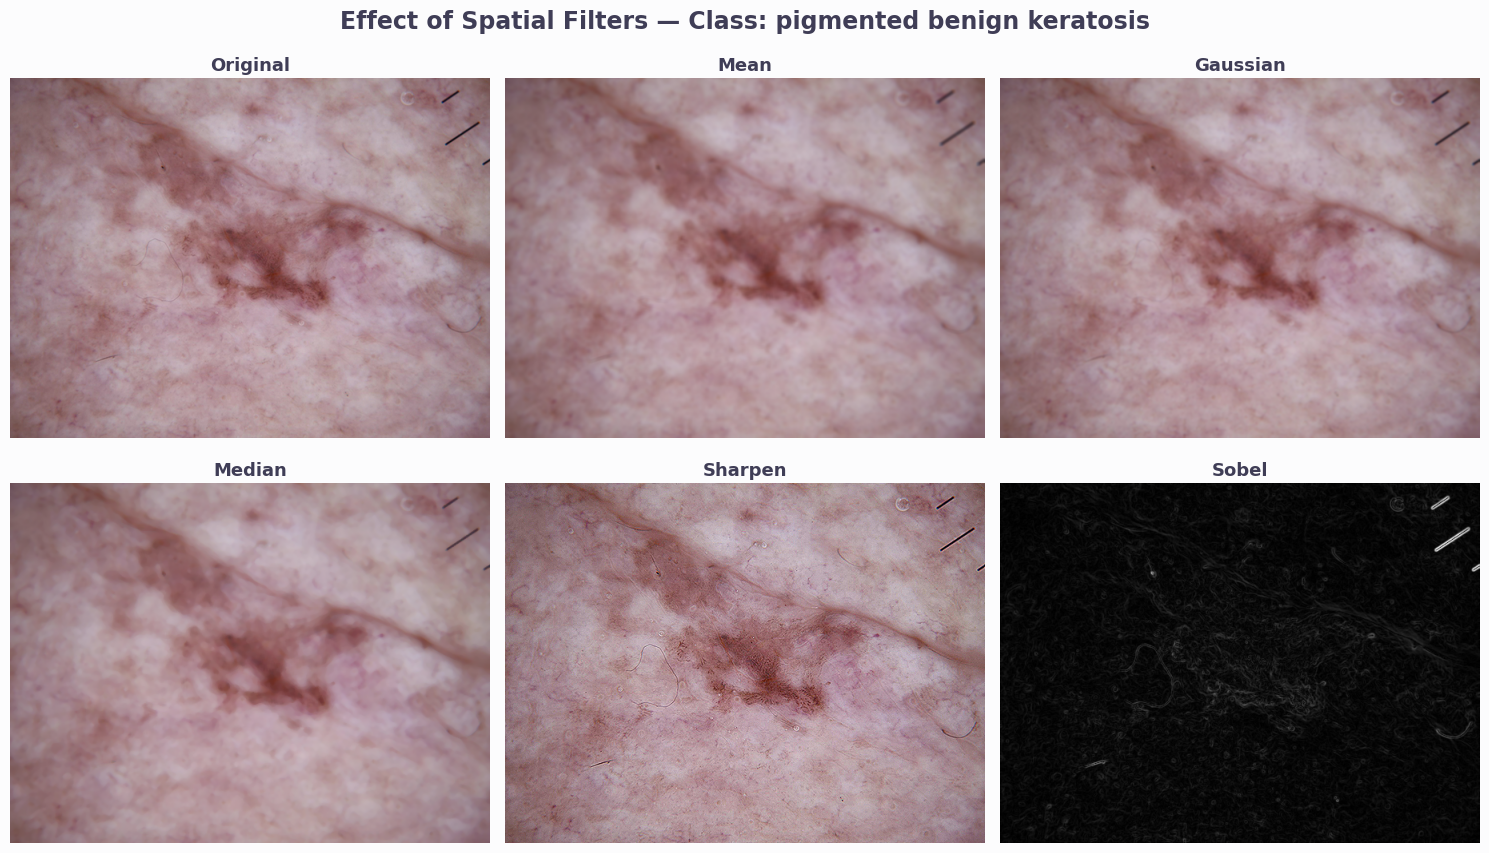

Sample image: /kaggle/input/skin-cancer9-classesisic/Skin cancer ISIC The International Skin Imaging Collaboration/Train/pigmented benign keratosis/ISIC_0027652.jpg
Class: pigmented benign keratosis


In [6]:
# ============================================================
# CELL 6 — ORIGINAL VS FILTERED IMAGE VISUALIZATION
# ============================================================

# Select one image from the training dataset
sample_row = train_split_df.iloc[0]

image_path = sample_row["path"]
class_name = sample_row["class_name"]

original_image = Image.open(image_path).convert("RGB")


# Create figure
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

fig.patch.set_facecolor("#FCFCFD")

for ax, filter_name in zip(axes.flat, FILTERS):

    filtered_image = apply_filter(
        original_image,
        filter_name
    )

    ax.imshow(filtered_image)
    ax.set_title(
        filter_name,
        fontsize=13,
        fontweight="bold",
        color="#3F3D56"
    )
    ax.axis("off")


fig.suptitle(
    f"Effect of Spatial Filters — Class: {class_name}",
    fontsize=17,
    fontweight="bold",
    color="#3F3D56",
    y=0.98
)

plt.tight_layout()
plt.show()


print("Sample image:", image_path)
print("Class:", class_name)

In [7]:
# ============================================================
# CELL 7 — CUSTOM FILTERED DATASET
# ============================================================

class SkinLesionDataset(Dataset):

    def __init__(self, dataframe, transform=None, filter_name="Original"):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.filter_name = filter_name

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        # Load image
        image = Image.open(row["path"]).convert("RGB")

        # Apply selected spatial filter
        image = apply_filter(
            image,
            self.filter_name
        )

        # Apply resizing, augmentation and normalization
        if self.transform:
            image = self.transform(image)

        # Label
        label = torch.tensor(
            row["label"],
            dtype=torch.long
        )

        return image, label


print("=" * 60)
print("CUSTOM DATASET CREATED")
print("=" * 60)

print("\nDataset class: SkinLesionDataset")
print("Supported filters:")

for filter_name in FILTERS:
    print(" ✓", filter_name)

print("\nThe dataset can now load filtered images.")

CUSTOM DATASET CREATED

Dataset class: SkinLesionDataset
Supported filters:
 ✓ Original
 ✓ Mean
 ✓ Gaussian
 ✓ Median
 ✓ Sharpen
 ✓ Sobel

The dataset can now load filtered images.


In [8]:
# ============================================================
# CELL 8 — CREATE DATALOADERS
# ============================================================

BATCH_SIZE = 32
NUM_WORKERS = 2

# Dictionaries to store loaders for every filter
train_loaders = {}
val_loaders = {}
test_loaders = {}


for filter_name in FILTERS:

    print(f"Creating loaders for: {filter_name}")

    # Training dataset
    train_dataset = SkinLesionDataset(
        train_split_df,
        transform=train_transform,
        filter_name=filter_name
    )

    # Validation dataset
    val_dataset = SkinLesionDataset(
        val_df,
        transform=eval_transform,
        filter_name=filter_name
    )

    # Test dataset
    test_dataset = SkinLesionDataset(
        test_df,
        transform=eval_transform,
        filter_name=filter_name
    )

    # DataLoaders
    train_loaders[filter_name] = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    val_loaders[filter_name] = DataLoader(
        val_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )

    test_loaders[filter_name] = DataLoader(
        test_dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True
    )


print("\n" + "=" * 60)
print("ALL DATALOADERS CREATED")
print("=" * 60)

print("\nFilters:", FILTERS)
print("Batch size:", BATCH_SIZE)

print("\nTraining batches — Original:",
      len(train_loaders["Original"]))

print("Validation batches — Original:",
      len(val_loaders["Original"]))

print("Testing batches — Original:",
      len(test_loaders["Original"]))

Creating loaders for: Original
Creating loaders for: Mean
Creating loaders for: Gaussian
Creating loaders for: Median
Creating loaders for: Sharpen
Creating loaders for: Sobel

ALL DATALOADERS CREATED

Filters: ['Original', 'Mean', 'Gaussian', 'Median', 'Sharpen', 'Sobel']
Batch size: 32

Training batches — Original: 41
Validation batches — Original: 11
Testing batches — Original: 2


In [9]:
# ============================================================
# CELL 9 — PRETRAINED MODELS
# ============================================================

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", DEVICE)


def create_model(model_name):

    # --------------------------------------------------------
    # VGG19
    # --------------------------------------------------------
    if model_name == "VGG19":

        model = models.vgg19(
            weights=models.VGG19_Weights.DEFAULT
        )

        # Replace final classifier
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # EfficientNet-B0
    # --------------------------------------------------------
    elif model_name == "EfficientNet-B0":

        model = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )

        # Replace final classifier
        model.classifier[1] = nn.Linear(
            model.classifier[1].in_features,
            NUM_CLASSES
        )


    # --------------------------------------------------------
    # AlexNet
    # --------------------------------------------------------
    elif model_name == "AlexNet":

        model = models.alexnet(
            weights=models.AlexNet_Weights.DEFAULT
        )

        # Replace final classifier
        model.classifier[6] = nn.Linear(
            model.classifier[6].in_features,
            NUM_CLASSES
        )


    else:
        raise ValueError(
            f"Unknown model: {model_name}"
        )

    return model.to(DEVICE)


MODEL_NAMES = [
    "VGG19",
    "EfficientNet-B0",
    "AlexNet"
]


# Test model creation
for model_name in MODEL_NAMES:

    model = create_model(model_name)

    print(
        f"✓ {model_name} loaded successfully"
    )

print("\nNumber of classes:", NUM_CLASSES)
print("Classes:", SELECTED_CLASSES)

Using device: cuda
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth


100%|██████████| 548M/548M [00:05<00:00, 99.9MB/s]


✓ VGG19 loaded successfully
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 138MB/s]


✓ EfficientNet-B0 loaded successfully
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 127MB/s]


✓ AlexNet loaded successfully

Number of classes: 4
Classes: ['melanoma', 'pigmented benign keratosis', 'basal cell carcinoma', 'nevus']


In [10]:
# ============================================================
# CELL 10 — TRAINING FUNCTION
# ============================================================

EPOCHS = 10
LEARNING_RATE = 0.0001


# ------------------------------------------------------------
# Calculate class weights from the training split
# ------------------------------------------------------------

class_counts = (
    train_split_df["label"]
    .value_counts()
    .sort_index()
    .values
)

class_weights = (
    len(train_split_df)
    / (NUM_CLASSES * class_counts)
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)


print("Class weights:")
for i, weight in enumerate(class_weights):
    print(
        f"{SELECTED_CLASSES[i]}: {weight.item():.4f}"
    )


# ------------------------------------------------------------
# Training function
# ------------------------------------------------------------

def train_model(model, train_loader, val_loader):

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(EPOCHS):

        # ====================================================
        # TRAINING
        # ====================================================

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()
            optimizer.step()

            running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

        train_loss = running_loss / total
        train_accuracy = correct / total


        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        val_running_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():

            for images, labels in val_loader:

                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

                val_running_loss += (
                    loss.item() * images.size(0)
                )

                predictions = outputs.argmax(dim=1)

                val_correct += (
                    predictions == labels
                ).sum().item()

                val_total += labels.size(0)

        val_loss = val_running_loss / val_total
        val_accuracy = val_correct / val_total


        # ====================================================
        # SAVE HISTORY
        # ====================================================

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_accuracy"].append(val_accuracy)


        print(
            f"Epoch [{epoch + 1:02d}/{EPOCHS}] | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f}"
        )


    return history


print("\nTraining function created successfully.")
print("Epochs:", EPOCHS)
print("Learning rate:", LEARNING_RATE)

Class weights:
melanoma: 0.9329
pigmented benign keratosis: 0.8848
basal cell carcinoma: 1.0847
nevus: 1.1416

Training function created successfully.
Epochs: 10
Learning rate: 0.0001


In [11]:
# ============================================================
# CELL 11 — EVALUATION FUNCTION
# ============================================================

def evaluate_model(model, data_loader):

    model.eval()

    all_labels = []
    all_predictions = []
    all_probabilities = []

    with torch.no_grad():

        for images, labels in data_loader:

            images = images.to(DEVICE)

            outputs = model(images)

            probabilities = torch.softmax(
                outputs,
                dim=1
            )

            predictions = probabilities.argmax(
                dim=1
            )

            all_labels.extend(
                labels.numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

            all_probabilities.extend(
                probabilities.cpu().numpy()
            )


    # Convert to NumPy arrays
    y_true = np.array(all_labels)
    y_pred = np.array(all_predictions)
    y_prob = np.array(all_probabilities)


    # --------------------------------------------------------
    # Required metrics
    # --------------------------------------------------------

    accuracy = accuracy_score(
        y_true,
        y_pred
    )

    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    balanced_acc = balanced_accuracy_score(
        y_true,
        y_pred
    )


    # --------------------------------------------------------
    # Multi-class AUC
    # --------------------------------------------------------

    try:

        auc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro"
        )

    except ValueError:

        auc = np.nan


    # --------------------------------------------------------
    # Confusion matrix + per-class report
    # --------------------------------------------------------

    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES))
    )

    report = classification_report(
        y_true,
        y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=SELECTED_CLASSES,
        output_dict=True,
        zero_division=0
    )


    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "macro_f1": macro_f1,
        "balanced_accuracy": balanced_acc,
        "auc": auc,
        "confusion_matrix": cm,
        "classification_report": report,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": y_prob
    }


print("=" * 60)
print("EVALUATION FUNCTION CREATED")
print("=" * 60)

print("\nMetrics:")
print("✓ Accuracy")
print("✓ Precision")
print("✓ Recall")
print("✓ F1-score")
print("✓ Macro-F1")
print("✓ Balanced Accuracy")
print("✓ AUC")
print("✓ Confusion Matrix")
print("✓ Per-class Precision / Recall / F1")

EVALUATION FUNCTION CREATED

Metrics:
✓ Accuracy
✓ Precision
✓ Recall
✓ F1-score
✓ Macro-F1
✓ Balanced Accuracy
✓ AUC
✓ Confusion Matrix
✓ Per-class Precision / Recall / F1


In [12]:
# ============================================================
# CELL 12 — QUICK PIPELINE TEST
# ============================================================

print("=" * 60)
print("TESTING ONE MODEL")
print("=" * 60)

# Create VGG19
test_model = create_model("VGG19")

# Get Original-image loaders
test_train_loader = train_loaders["Original"]
test_val_loader = val_loaders["Original"]
test_test_loader = test_loaders["Original"]

print("\nModel created: VGG19")
print("Training batches:", len(test_train_loader))
print("Validation batches:", len(test_val_loader))
print("Testing batches:", len(test_test_loader))


# ------------------------------------------------------------
# Check one batch
# ------------------------------------------------------------

images, labels = next(iter(test_train_loader))

print("\nOne batch loaded successfully!")
print("Image shape:", images.shape)
print("Labels shape:", labels.shape)


# ------------------------------------------------------------
# Check model output
# ------------------------------------------------------------

with torch.no_grad():
    outputs = test_model(images.to(DEVICE))

print("Model output shape:", outputs.shape)

print("\nExpected:")
print("Image shape: [batch_size, 3, 224, 224]")
print("Model output: [batch_size, 4]")


# Free test model memory
del test_model
torch.cuda.empty_cache()

print("\n" + "=" * 60)
print("PIPELINE TEST COMPLETED SUCCESSFULLY")
print("=" * 60)

TESTING ONE MODEL

Model created: VGG19
Training batches: 41
Validation batches: 11
Testing batches: 2

One batch loaded successfully!
Image shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Model output shape: torch.Size([32, 4])

Expected:
Image shape: [batch_size, 3, 224, 224]
Model output: [batch_size, 4]

PIPELINE TEST COMPLETED SUCCESSFULLY


In [13]:
# ============================================================
# CELL 13 — VGG19 BASELINE (ORIGINAL IMAGES)
# ============================================================

print("=" * 60)
print("VGG19 — ORIGINAL IMAGES (BASELINE)")
print("=" * 60)

# Create a fresh pretrained VGG19
model = create_model("VGG19")

# Train using original images
history = train_model(
    model,
    train_loaders["Original"],
    val_loaders["Original"]
)

print("\nTraining completed.")

# Evaluate on the test set
results = evaluate_model(
    model,
    test_loaders["Original"]
)

print("\n" + "=" * 60)
print("VGG19 BASELINE TEST RESULTS")
print("=" * 60)

print(f"Accuracy          : {results['accuracy']:.4f}")
print(f"Precision         : {results['precision']:.4f}")
print(f"Recall            : {results['recall']:.4f}")
print(f"F1-score          : {results['f1']:.4f}")
print(f"Macro-F1          : {results['macro_f1']:.4f}")
print(f"Balanced Accuracy : {results['balanced_accuracy']:.4f}")
print(f"AUC               : {results['auc']:.4f}")

VGG19 — ORIGINAL IMAGES (BASELINE)
Epoch [01/10] | Train Loss: 1.1431 | Train Acc: 0.4632 | Val Loss: 0.9484 | Val Acc: 0.5933
Epoch [02/10] | Train Loss: 0.8790 | Train Acc: 0.6332 | Val Loss: 0.7676 | Val Acc: 0.6911
Epoch [03/10] | Train Loss: 0.6917 | Train Acc: 0.7420 | Val Loss: 0.6543 | Val Acc: 0.7523
Epoch [04/10] | Train Loss: 0.6042 | Train Acc: 0.7818 | Val Loss: 0.7457 | Val Acc: 0.7217
Epoch [05/10] | Train Loss: 0.6134 | Train Acc: 0.7672 | Val Loss: 0.5742 | Val Acc: 0.7951
Epoch [06/10] | Train Loss: 0.4693 | Train Acc: 0.8254 | Val Loss: 0.4773 | Val Acc: 0.8196
Epoch [07/10] | Train Loss: 0.4766 | Train Acc: 0.8216 | Val Loss: 0.6206 | Val Acc: 0.7645
Epoch [08/10] | Train Loss: 0.3979 | Train Acc: 0.8461 | Val Loss: 0.5685 | Val Acc: 0.7920
Epoch [09/10] | Train Loss: 0.3711 | Train Acc: 0.8622 | Val Loss: 0.6122 | Val Acc: 0.8104
Epoch [10/10] | Train Loss: 0.4246 | Train Acc: 0.8461 | Val Loss: 0.5604 | Val Acc: 0.8043

Training completed.

VGG19 BASELINE TEST RES

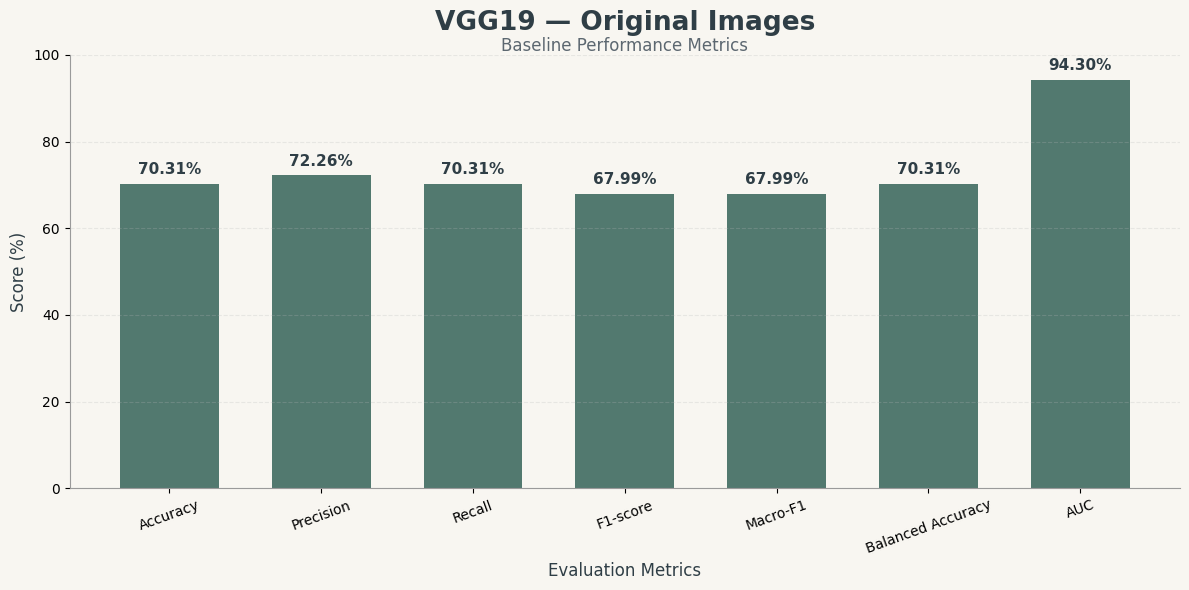

VGG19 BASELINE SAVED SUCCESSFULLY

Accuracy          : 70.31%
Precision         : 72.26%
Recall            : 70.31%
F1-score          : 67.99%
Macro-F1          : 67.99%
Balanced Accuracy : 70.31%
AUC               : 94.30%


In [14]:
# ============================================================
# CELL 14 — SAVE VGG19 BASELINE + BAR GRAPH
# ============================================================

experiment_results = {}
experiment_histories = {}

experiment_results["VGG19_Original"] = {
    "Model": "VGG19",
    "Filter": "Original",
    "Accuracy": results["accuracy"],
    "Precision": results["precision"],
    "Recall": results["recall"],
    "F1-score": results["f1"],
    "Macro-F1": results["macro_f1"],
    "Balanced Accuracy": results["balanced_accuracy"],
    "AUC": results["auc"],
    "Confusion Matrix": results["confusion_matrix"],
    "Classification Report": results["classification_report"]
}

experiment_histories["VGG19_Original"] = history

# ------------------------------------------------------------
# BAR GRAPH — VGG19 ORIGINAL BASELINE
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Macro-F1",
    "Balanced Accuracy",
    "AUC"
]

scores = [
    results["accuracy"] * 100,
    results["precision"] * 100,
    results["recall"] * 100,
    results["f1"] * 100,
    results["macro_f1"] * 100,
    results["balanced_accuracy"] * 100,
    results["auc"] * 100
]

deep_sage = "#52796F"
cream = "#F8F6F1"
dark_text = "#2F3E46"
grid_color = "#B8B8B8"

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor(cream)
ax.set_facecolor(cream)

bars = ax.bar(
    metrics,
    scores,
    color=deep_sage,
    width=0.65
)

ax.set_title(
    "VGG19 — Original Images",
    fontsize=19,
    fontweight="bold",
    color=dark_text,
    pad=18
)

ax.text(
    0.5,
    1.01,
    "Baseline Performance Metrics",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#5C6770"
)

ax.set_xlabel(
    "Evaluation Metrics",
    fontsize=12,
    color=dark_text
)

ax.set_ylabel(
    "Score (%)",
    fontsize=12,
    color=dark_text
)

ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    linestyle="--",
    color=grid_color,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#9A9A9A")
ax.spines["bottom"].set_color("#9A9A9A")

# Add percentage values above bars
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 1.5,
        f"{score:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=dark_text
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# DISPLAY BASELINE RESULTS
# ------------------------------------------------------------

print("=" * 60)
print("VGG19 BASELINE SAVED SUCCESSFULLY")
print("=" * 60)

print(f"\nAccuracy          : {results['accuracy']:.2%}")
print(f"Precision         : {results['precision']:.2%}")
print(f"Recall            : {results['recall']:.2%}")
print(f"F1-score          : {results['f1']:.2%}")
print(f"Macro-F1          : {results['macro_f1']:.2%}")
print(f"Balanced Accuracy : {results['balanced_accuracy']:.2%}")
print(f"AUC               : {results['auc']:.2%}")

VGG19 — MEAN FILTER
Epoch [01/10] | Train Loss: 1.2643 | Train Acc: 0.3576 | Val Loss: 1.0074 | Val Acc: 0.5688
Epoch [02/10] | Train Loss: 0.9216 | Train Acc: 0.5796 | Val Loss: 0.8272 | Val Acc: 0.6667
Epoch [03/10] | Train Loss: 0.8209 | Train Acc: 0.6723 | Val Loss: 0.7101 | Val Acc: 0.7003
Epoch [04/10] | Train Loss: 0.6838 | Train Acc: 0.7389 | Val Loss: 0.7861 | Val Acc: 0.6697
Epoch [05/10] | Train Loss: 0.5848 | Train Acc: 0.7887 | Val Loss: 0.5701 | Val Acc: 0.7829
Epoch [06/10] | Train Loss: 0.5848 | Train Acc: 0.7910 | Val Loss: 0.7952 | Val Acc: 0.7064
Epoch [07/10] | Train Loss: 0.5446 | Train Acc: 0.7994 | Val Loss: 0.5510 | Val Acc: 0.7920
Epoch [08/10] | Train Loss: 0.5002 | Train Acc: 0.8070 | Val Loss: 0.5151 | Val Acc: 0.7798
Epoch [09/10] | Train Loss: 0.4355 | Train Acc: 0.8384 | Val Loss: 0.6703 | Val Acc: 0.7462
Epoch [10/10] | Train Loss: 0.4349 | Train Acc: 0.8423 | Val Loss: 0.4758 | Val Acc: 0.8196

Training completed.


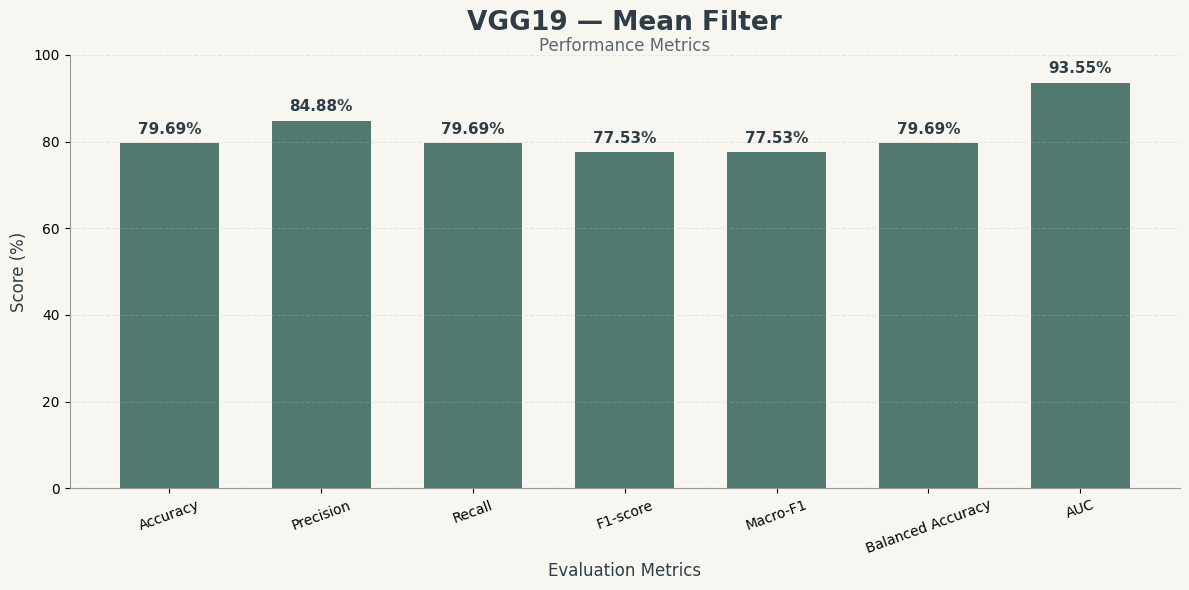

VGG19 — MEAN FILTER RESULTS

Accuracy          : 79.69%
Precision         : 84.88%
Recall            : 79.69%
F1-score          : 77.53%
Macro-F1          : 77.53%
Balanced Accuracy : 79.69%
AUC               : 93.55%


In [15]:
# ============================================================
# CELL 15 — VGG19 + MEAN FILTER
# ============================================================

print("=" * 60)
print("VGG19 — MEAN FILTER")
print("=" * 60)

# Create a fresh VGG19 model
model = create_model("VGG19")

# Train using Mean-filtered images
history = train_model(
    model,
    train_loaders["Mean"],
    val_loaders["Mean"]
)

print("\nTraining completed.")

# Evaluate on Mean-filtered test images
results = evaluate_model(
    model,
    test_loaders["Mean"]
)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

experiment_results["VGG19_Mean"] = {
    "Model": "VGG19",
    "Filter": "Mean",
    "Accuracy": results["accuracy"],
    "Precision": results["precision"],
    "Recall": results["recall"],
    "F1-score": results["f1"],
    "Macro-F1": results["macro_f1"],
    "Balanced Accuracy": results["balanced_accuracy"],
    "AUC": results["auc"],
    "Confusion Matrix": results["confusion_matrix"],
    "Classification Report": results["classification_report"]
}

experiment_histories["VGG19_Mean"] = history

# ------------------------------------------------------------
# BAR GRAPH
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Macro-F1",
    "Balanced Accuracy",
    "AUC"
]

scores = [
    results["accuracy"] * 100,
    results["precision"] * 100,
    results["recall"] * 100,
    results["f1"] * 100,
    results["macro_f1"] * 100,
    results["balanced_accuracy"] * 100,
    results["auc"] * 100
]

deep_sage = "#52796F"
cream = "#F8F6F1"
dark_text = "#2F3E46"
grid_color = "#B8B8B8"

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor(cream)
ax.set_facecolor(cream)

bars = ax.bar(
    metrics,
    scores,
    color=deep_sage,
    width=0.65
)

ax.set_title(
    "VGG19 — Mean Filter",
    fontsize=19,
    fontweight="bold",
    color=dark_text,
    pad=18
)

ax.text(
    0.5,
    1.01,
    "Performance Metrics",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#5C6770"
)

ax.set_xlabel(
    "Evaluation Metrics",
    fontsize=12,
    color=dark_text
)

ax.set_ylabel(
    "Score (%)",
    fontsize=12,
    color=dark_text
)

ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    linestyle="--",
    color=grid_color,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#9A9A9A")
ax.spines["bottom"].set_color("#9A9A9A")

# Add percentage values
for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 1.5,
        f"{score:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=dark_text
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("=" * 60)
print("VGG19 — MEAN FILTER RESULTS")
print("=" * 60)

print(f"\nAccuracy          : {results['accuracy']:.2%}")
print(f"Precision         : {results['precision']:.2%}")
print(f"Recall            : {results['recall']:.2%}")
print(f"F1-score          : {results['f1']:.2%}")
print(f"Macro-F1          : {results['macro_f1']:.2%}")
print(f"Balanced Accuracy : {results['balanced_accuracy']:.2%}")
print(f"AUC               : {results['auc']:.2%}")

VGG19 — GAUSSIAN FILTER
Epoch [01/10] | Train Loss: 1.1982 | Train Acc: 0.4403 | Val Loss: 1.3602 | Val Acc: 0.4281
Epoch [02/10] | Train Loss: 0.9930 | Train Acc: 0.5743 | Val Loss: 0.9133 | Val Acc: 0.6239
Epoch [03/10] | Train Loss: 0.8671 | Train Acc: 0.6478 | Val Loss: 0.7232 | Val Acc: 0.7309
Epoch [04/10] | Train Loss: 0.7115 | Train Acc: 0.7274 | Val Loss: 0.5961 | Val Acc: 0.7737
Epoch [05/10] | Train Loss: 0.7100 | Train Acc: 0.7190 | Val Loss: 0.6067 | Val Acc: 0.7615
Epoch [06/10] | Train Loss: 0.5865 | Train Acc: 0.7787 | Val Loss: 0.6195 | Val Acc: 0.7645
Epoch [07/10] | Train Loss: 0.5176 | Train Acc: 0.8086 | Val Loss: 0.6339 | Val Acc: 0.7798
Epoch [08/10] | Train Loss: 0.4573 | Train Acc: 0.8224 | Val Loss: 0.5145 | Val Acc: 0.7737
Epoch [09/10] | Train Loss: 0.4654 | Train Acc: 0.8239 | Val Loss: 0.5628 | Val Acc: 0.8135
Epoch [10/10] | Train Loss: 0.4625 | Train Acc: 0.8239 | Val Loss: 0.5627 | Val Acc: 0.7768

Training completed.


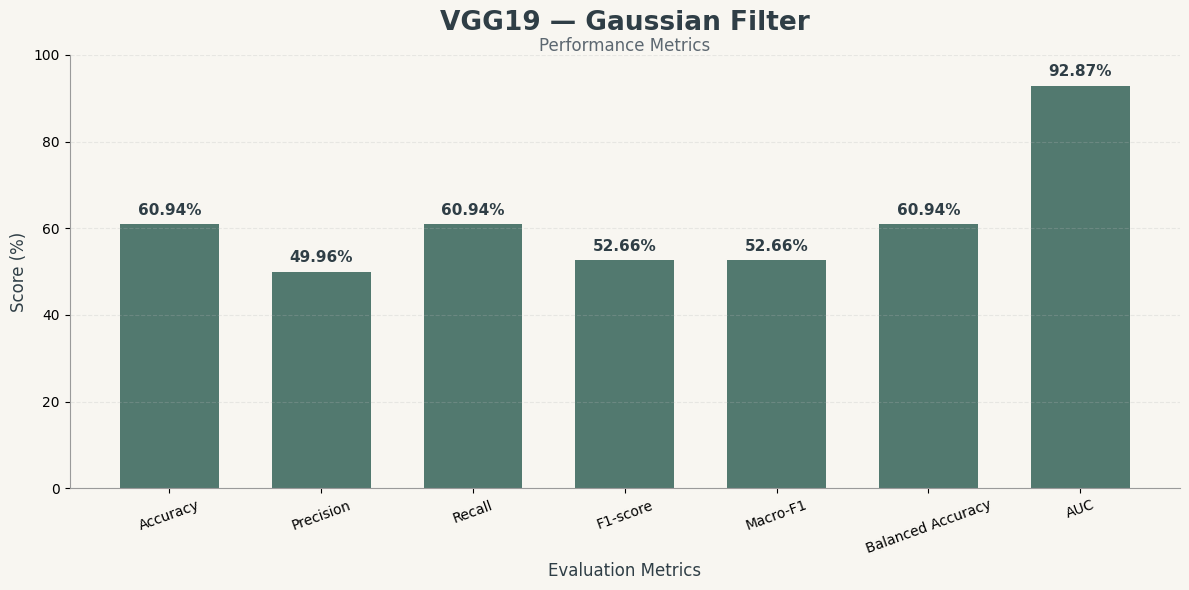

VGG19 — GAUSSIAN FILTER RESULTS

Accuracy          : 60.94%
Precision         : 49.96%
Recall            : 60.94%
F1-score          : 52.66%
Macro-F1          : 52.66%
Balanced Accuracy : 60.94%
AUC               : 92.87%


In [16]:
# ============================================================
# CELL 16 — VGG19 + GAUSSIAN FILTER
# ============================================================

print("=" * 60)
print("VGG19 — GAUSSIAN FILTER")
print("=" * 60)

# Create a fresh VGG19 model
model = create_model("VGG19")

# Train using Gaussian-filtered images
history = train_model(
    model,
    train_loaders["Gaussian"],
    val_loaders["Gaussian"]
)

print("\nTraining completed.")

# Evaluate on Gaussian-filtered test images
results = evaluate_model(
    model,
    test_loaders["Gaussian"]
)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

experiment_results["VGG19_Gaussian"] = {
    "Model": "VGG19",
    "Filter": "Gaussian",
    "Accuracy": results["accuracy"],
    "Precision": results["precision"],
    "Recall": results["recall"],
    "F1-score": results["f1"],
    "Macro-F1": results["macro_f1"],
    "Balanced Accuracy": results["balanced_accuracy"],
    "AUC": results["auc"],
    "Confusion Matrix": results["confusion_matrix"],
    "Classification Report": results["classification_report"]
}

experiment_histories["VGG19_Gaussian"] = history

# ------------------------------------------------------------
# BAR GRAPH
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Macro-F1",
    "Balanced Accuracy",
    "AUC"
]

scores = [
    results["accuracy"] * 100,
    results["precision"] * 100,
    results["recall"] * 100,
    results["f1"] * 100,
    results["macro_f1"] * 100,
    results["balanced_accuracy"] * 100,
    results["auc"] * 100
]

deep_sage = "#52796F"
cream = "#F8F6F1"
dark_text = "#2F3E46"
grid_color = "#B8B8B8"

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor(cream)
ax.set_facecolor(cream)

bars = ax.bar(
    metrics,
    scores,
    color=deep_sage,
    width=0.65
)

ax.set_title(
    "VGG19 — Gaussian Filter",
    fontsize=19,
    fontweight="bold",
    color=dark_text,
    pad=18
)

ax.text(
    0.5,
    1.01,
    "Performance Metrics",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#5C6770"
)

ax.set_xlabel(
    "Evaluation Metrics",
    fontsize=12,
    color=dark_text
)

ax.set_ylabel(
    "Score (%)",
    fontsize=12,
    color=dark_text
)

ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    linestyle="--",
    color=grid_color,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#9A9A9A")
ax.spines["bottom"].set_color("#9A9A9A")

for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 1.5,
        f"{score:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=dark_text
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("=" * 60)
print("VGG19 — GAUSSIAN FILTER RESULTS")
print("=" * 60)

print(f"\nAccuracy          : {results['accuracy']:.2%}")
print(f"Precision         : {results['precision']:.2%}")
print(f"Recall            : {results['recall']:.2%}")
print(f"F1-score          : {results['f1']:.2%}")
print(f"Macro-F1          : {results['macro_f1']:.2%}")
print(f"Balanced Accuracy : {results['balanced_accuracy']:.2%}")
print(f"AUC               : {results['auc']:.2%}")

VGG19 — MEDIAN FILTER
Epoch [01/10] | Train Loss: 1.2007 | Train Acc: 0.4089 | Val Loss: 0.9582 | Val Acc: 0.5627
Epoch [02/10] | Train Loss: 0.9388 | Train Acc: 0.5750 | Val Loss: 0.8212 | Val Acc: 0.6239
Epoch [03/10] | Train Loss: 0.7282 | Train Acc: 0.7083 | Val Loss: 0.7698 | Val Acc: 0.7737
Epoch [04/10] | Train Loss: 0.6620 | Train Acc: 0.7489 | Val Loss: 0.7708 | Val Acc: 0.7248
Epoch [05/10] | Train Loss: 0.5683 | Train Acc: 0.8009 | Val Loss: 0.7299 | Val Acc: 0.7401
Epoch [06/10] | Train Loss: 0.4846 | Train Acc: 0.8277 | Val Loss: 0.6993 | Val Acc: 0.7370
Epoch [07/10] | Train Loss: 0.5652 | Train Acc: 0.7818 | Val Loss: 0.6036 | Val Acc: 0.7737
Epoch [08/10] | Train Loss: 0.4307 | Train Acc: 0.8553 | Val Loss: 0.4700 | Val Acc: 0.8349
Epoch [09/10] | Train Loss: 0.3945 | Train Acc: 0.8538 | Val Loss: 0.7164 | Val Acc: 0.7187
Epoch [10/10] | Train Loss: 0.3624 | Train Acc: 0.8783 | Val Loss: 0.7562 | Val Acc: 0.7645

Training completed.


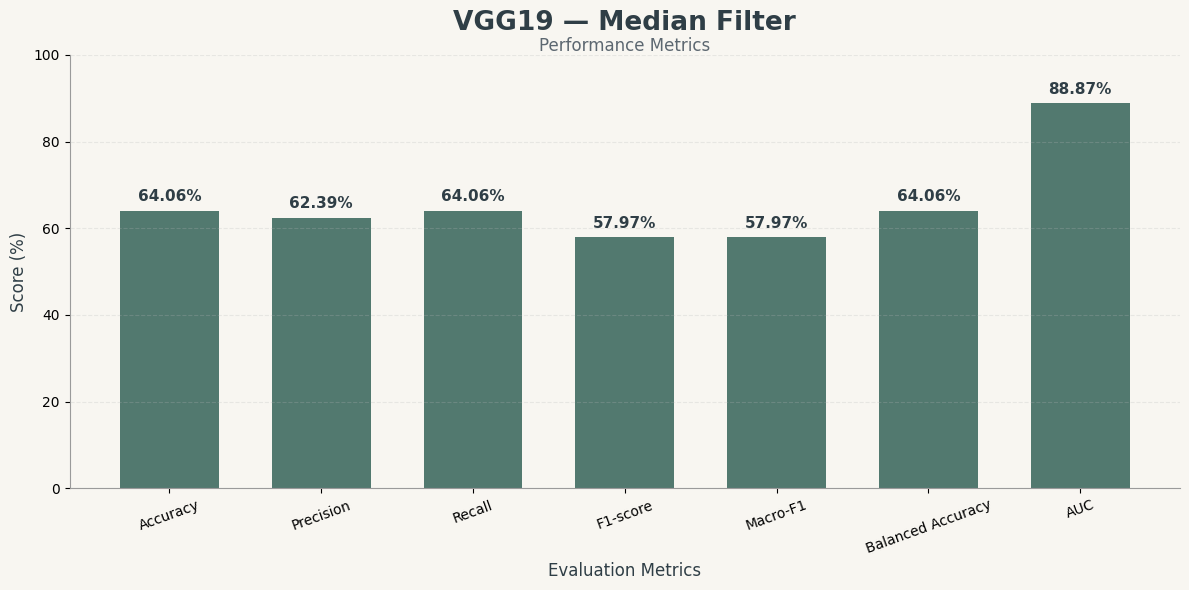

VGG19 — MEDIAN FILTER RESULTS

Accuracy          : 64.06%
Precision         : 62.39%
Recall            : 64.06%
F1-score          : 57.97%
Macro-F1          : 57.97%
Balanced Accuracy : 64.06%
AUC               : 88.87%


In [17]:

# CELL 17 — VGG19 + MEDIAN FILTER


print("=" * 60)
print("VGG19 — MEDIAN FILTER")
print("=" * 60)

model = create_model("VGG19")

history = train_model(
    model,
    train_loaders["Median"],
    val_loaders["Median"]
)

print("\nTraining completed.")

results = evaluate_model(
    model,
    test_loaders["Median"]
)

# Save results
experiment_results["VGG19_Median"] = {
    "Model": "VGG19",
    "Filter": "Median",
    "Accuracy": results["accuracy"],
    "Precision": results["precision"],
    "Recall": results["recall"],
    "F1-score": results["f1"],
    "Macro-F1": results["macro_f1"],
    "Balanced Accuracy": results["balanced_accuracy"],
    "AUC": results["auc"],
    "Confusion Matrix": results["confusion_matrix"],
    "Classification Report": results["classification_report"]
}

experiment_histories["VGG19_Median"] = history

# Bar graph
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Macro-F1",
    "Balanced Accuracy",
    "AUC"
]

scores = [
    results["accuracy"] * 100,
    results["precision"] * 100,
    results["recall"] * 100,
    results["f1"] * 100,
    results["macro_f1"] * 100,
    results["balanced_accuracy"] * 100,
    results["auc"] * 100
]

deep_sage = "#52796F"
cream = "#F8F6F1"
dark_text = "#2F3E46"
grid_color = "#B8B8B8"

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor(cream)
ax.set_facecolor(cream)

bars = ax.bar(metrics, scores, color=deep_sage, width=0.65)

ax.set_title(
    "VGG19 — Median Filter",
    fontsize=19,
    fontweight="bold",
    color=dark_text,
    pad=18
)

ax.text(
    0.5, 1.01,
    "Performance Metrics",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#5C6770"
)

ax.set_xlabel("Evaluation Metrics", fontsize=12, color=dark_text)
ax.set_ylabel("Score (%)", fontsize=12, color=dark_text)
ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    linestyle="--",
    color=grid_color,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#9A9A9A")
ax.spines["bottom"].set_color("#9A9A9A")

for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 1.5,
        f"{score:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=dark_text
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

print("=" * 60)
print("VGG19 — MEDIAN FILTER RESULTS")
print("=" * 60)

print(f"\nAccuracy          : {results['accuracy']:.2%}")
print(f"Precision         : {results['precision']:.2%}")
print(f"Recall            : {results['recall']:.2%}")
print(f"F1-score          : {results['f1']:.2%}")
print(f"Macro-F1          : {results['macro_f1']:.2%}")
print(f"Balanced Accuracy : {results['balanced_accuracy']:.2%}")
print(f"AUC               : {results['auc']:.2%}")

VGG19 — SHARPEN FILTER
Epoch [01/10] | Train Loss: 1.2135 | Train Acc: 0.4196 | Val Loss: 0.9903 | Val Acc: 0.5168
Epoch [02/10] | Train Loss: 0.8998 | Train Acc: 0.5888 | Val Loss: 0.8163 | Val Acc: 0.5627
Epoch [03/10] | Train Loss: 0.8059 | Train Acc: 0.6753 | Val Loss: 0.7375 | Val Acc: 0.6758
Epoch [04/10] | Train Loss: 0.6441 | Train Acc: 0.7496 | Val Loss: 0.6193 | Val Acc: 0.7798
Epoch [05/10] | Train Loss: 0.5301 | Train Acc: 0.8040 | Val Loss: 0.5282 | Val Acc: 0.8043
Epoch [06/10] | Train Loss: 0.5129 | Train Acc: 0.7902 | Val Loss: 0.5848 | Val Acc: 0.7584
Epoch [07/10] | Train Loss: 0.4070 | Train Acc: 0.8354 | Val Loss: 0.4510 | Val Acc: 0.8165
Epoch [08/10] | Train Loss: 0.4038 | Train Acc: 0.8415 | Val Loss: 0.4547 | Val Acc: 0.8196
Epoch [09/10] | Train Loss: 0.4092 | Train Acc: 0.8507 | Val Loss: 0.4451 | Val Acc: 0.8318
Epoch [10/10] | Train Loss: 0.3925 | Train Acc: 0.8438 | Val Loss: 0.6099 | Val Acc: 0.7768

Training completed.


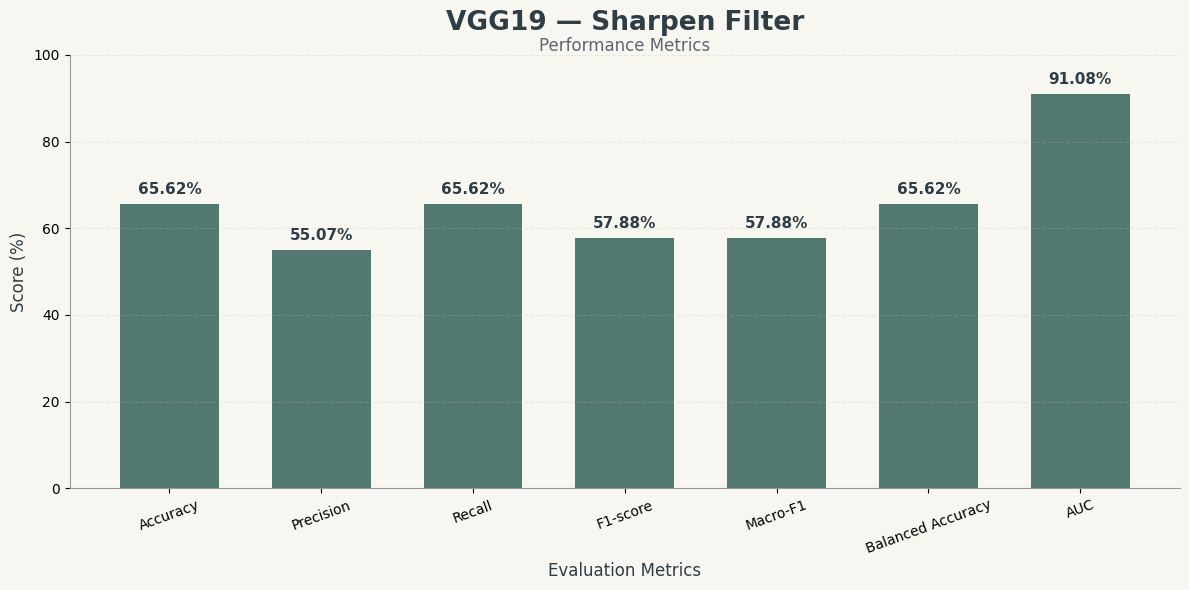

VGG19 — SHARPEN FILTER RESULTS

Accuracy          : 65.62%
Precision         : 55.07%
Recall            : 65.62%
F1-score          : 57.88%
Macro-F1          : 57.88%
Balanced Accuracy : 65.62%
AUC               : 91.08%


In [18]:
# ============================================================
# CELL 18 — VGG19 + SHARPEN FILTER
# ============================================================

print("=" * 60)
print("VGG19 — SHARPEN FILTER")
print("=" * 60)

model = create_model("VGG19")

history = train_model(
    model,
    train_loaders["Sharpen"],
    val_loaders["Sharpen"]
)

print("\nTraining completed.")

results = evaluate_model(
    model,
    test_loaders["Sharpen"]
)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

experiment_results["VGG19_Sharpen"] = {
    "Model": "VGG19",
    "Filter": "Sharpen",
    "Accuracy": results["accuracy"],
    "Precision": results["precision"],
    "Recall": results["recall"],
    "F1-score": results["f1"],
    "Macro-F1": results["macro_f1"],
    "Balanced Accuracy": results["balanced_accuracy"],
    "AUC": results["auc"],
    "Confusion Matrix": results["confusion_matrix"],
    "Classification Report": results["classification_report"]
}

experiment_histories["VGG19_Sharpen"] = history

# ------------------------------------------------------------
# BAR GRAPH
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Macro-F1",
    "Balanced Accuracy",
    "AUC"
]

scores = [
    results["accuracy"] * 100,
    results["precision"] * 100,
    results["recall"] * 100,
    results["f1"] * 100,
    results["macro_f1"] * 100,
    results["balanced_accuracy"] * 100,
    results["auc"] * 100
]

deep_sage = "#52796F"
cream = "#F8F6F1"
dark_text = "#2F3E46"
grid_color = "#B8B8B8"

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor(cream)
ax.set_facecolor(cream)

bars = ax.bar(
    metrics,
    scores,
    color=deep_sage,
    width=0.65
)

ax.set_title(
    "VGG19 — Sharpen Filter",
    fontsize=19,
    fontweight="bold",
    color=dark_text,
    pad=18
)

ax.text(
    0.5,
    1.01,
    "Performance Metrics",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#5C6770"
)

ax.set_xlabel(
    "Evaluation Metrics",
    fontsize=12,
    color=dark_text
)

ax.set_ylabel(
    "Score (%)",
    fontsize=12,
    color=dark_text
)

ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    linestyle="--",
    color=grid_color,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#9A9A9A")
ax.spines["bottom"].set_color("#9A9A9A")

for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 1.5,
        f"{score:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=dark_text
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


# PRINT RESULTS


print("=" * 60)
print("VGG19 — SHARPEN FILTER RESULTS")
print("=" * 60)

print(f"\nAccuracy          : {results['accuracy']:.2%}")
print(f"Precision         : {results['precision']:.2%}")
print(f"Recall            : {results['recall']:.2%}")
print(f"F1-score          : {results['f1']:.2%}")
print(f"Macro-F1          : {results['macro_f1']:.2%}")
print(f"Balanced Accuracy : {results['balanced_accuracy']:.2%}")
print(f"AUC               : {results['auc']:.2%}")

VGG19 — SOBEL FILTER
Epoch [01/10] | Train Loss: 1.2851 | Train Acc: 0.3752 | Val Loss: 1.1701 | Val Acc: 0.4709
Epoch [02/10] | Train Loss: 1.1567 | Train Acc: 0.4426 | Val Loss: 1.2403 | Val Acc: 0.4006
Epoch [03/10] | Train Loss: 1.1224 | Train Acc: 0.4931 | Val Loss: 1.2472 | Val Acc: 0.4648
Epoch [04/10] | Train Loss: 1.0548 | Train Acc: 0.5115 | Val Loss: 1.2381 | Val Acc: 0.3639
Epoch [05/10] | Train Loss: 1.0262 | Train Acc: 0.5260 | Val Loss: 1.0965 | Val Acc: 0.5229
Epoch [06/10] | Train Loss: 0.9762 | Train Acc: 0.5505 | Val Loss: 0.9402 | Val Acc: 0.5780
Epoch [07/10] | Train Loss: 0.9164 | Train Acc: 0.6057 | Val Loss: 1.1273 | Val Acc: 0.4618
Epoch [08/10] | Train Loss: 0.9811 | Train Acc: 0.5735 | Val Loss: 1.0659 | Val Acc: 0.5841
Epoch [09/10] | Train Loss: 0.8924 | Train Acc: 0.6057 | Val Loss: 0.9270 | Val Acc: 0.6147
Epoch [10/10] | Train Loss: 0.8559 | Train Acc: 0.6325 | Val Loss: 1.0005 | Val Acc: 0.5657

Training completed.


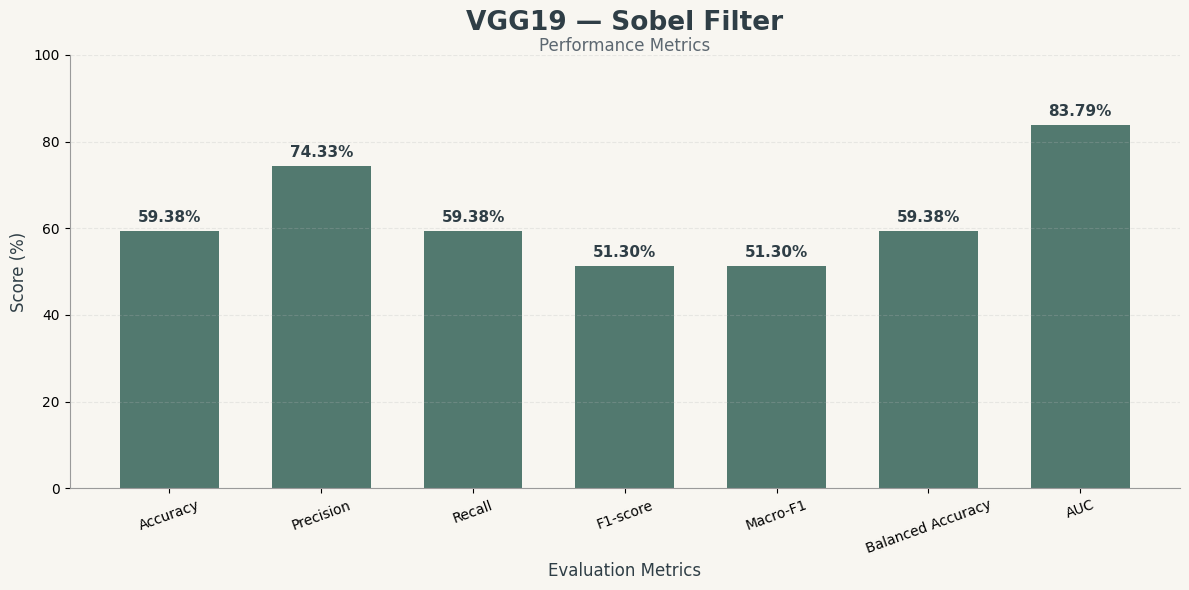

VGG19 — SOBEL FILTER RESULTS

Accuracy          : 59.38%
Precision         : 74.33%
Recall            : 59.38%
F1-score          : 51.30%
Macro-F1          : 51.30%
Balanced Accuracy : 59.38%
AUC               : 83.79%


In [19]:
# ============================================================
# CELL 19 — VGG19 + SOBEL FILTER
# ============================================================

print("=" * 60)
print("VGG19 — SOBEL FILTER")
print("=" * 60)

model = create_model("VGG19")

history = train_model(
    model,
    train_loaders["Sobel"],
    val_loaders["Sobel"]
)

print("\nTraining completed.")

results = evaluate_model(
    model,
    test_loaders["Sobel"]
)

# ------------------------------------------------------------
# SAVE RESULTS
# ------------------------------------------------------------

experiment_results["VGG19_Sobel"] = {
    "Model": "VGG19",
    "Filter": "Sobel",
    "Accuracy": results["accuracy"],
    "Precision": results["precision"],
    "Recall": results["recall"],
    "F1-score": results["f1"],
    "Macro-F1": results["macro_f1"],
    "Balanced Accuracy": results["balanced_accuracy"],
    "AUC": results["auc"],
    "Confusion Matrix": results["confusion_matrix"],
    "Classification Report": results["classification_report"]
}

experiment_histories["VGG19_Sobel"] = history

# ------------------------------------------------------------
# BAR GRAPH
# ------------------------------------------------------------

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score",
    "Macro-F1",
    "Balanced Accuracy",
    "AUC"
]

scores = [
    results["accuracy"] * 100,
    results["precision"] * 100,
    results["recall"] * 100,
    results["f1"] * 100,
    results["macro_f1"] * 100,
    results["balanced_accuracy"] * 100,
    results["auc"] * 100
]

deep_sage = "#52796F"
cream = "#F8F6F1"
dark_text = "#2F3E46"
grid_color = "#B8B8B8"

fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor(cream)
ax.set_facecolor(cream)

bars = ax.bar(
    metrics,
    scores,
    color=deep_sage,
    width=0.65
)

ax.set_title(
    "VGG19 — Sobel Filter",
    fontsize=19,
    fontweight="bold",
    color=dark_text,
    pad=18
)

ax.text(
    0.5,
    1.01,
    "Performance Metrics",
    transform=ax.transAxes,
    ha="center",
    fontsize=12,
    color="#5C6770"
)

ax.set_xlabel(
    "Evaluation Metrics",
    fontsize=12,
    color=dark_text
)

ax.set_ylabel(
    "Score (%)",
    fontsize=12,
    color=dark_text
)

ax.set_ylim(0, 100)

ax.grid(
    axis="y",
    linestyle="--",
    color=grid_color,
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#9A9A9A")
ax.spines["bottom"].set_color("#9A9A9A")

for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 1.5,
        f"{score:.2f}%",
        ha="center",
        va="bottom",
        fontsize=11,
        fontweight="bold",
        color=dark_text
    )

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# PRINT RESULTS
# ------------------------------------------------------------

print("=" * 60)
print("VGG19 — SOBEL FILTER RESULTS")
print("=" * 60)

print(f"\nAccuracy          : {results['accuracy']:.2%}")
print(f"Precision         : {results['precision']:.2%}")
print(f"Recall            : {results['recall']:.2%}")
print(f"F1-score          : {results['f1']:.2%}")
print(f"Macro-F1          : {results['macro_f1']:.2%}")
print(f"Balanced Accuracy : {results['balanced_accuracy']:.2%}")
print(f"AUC               : {results['auc']:.2%}")


VGG19 — OVERALL COMPARISON TABLE


,Model,Filter,Accuracy (%),Precision (%),Recall (%),F1-score (%),Macro-F1 (%),Balanced Accuracy (%),AUC (%)
0,VGG19,Original,70.31,72.26,70.31,67.99,67.99,70.31,94.30
1,VGG19,Mean,79.69,84.88,79.69,77.53,77.53,79.69,93.55
2,VGG19,Gaussian,60.94,49.96,60.94,52.66,52.66,60.94,92.87
3,VGG19,Median,64.06,62.39,64.06,57.97,57.97,64.06,88.87
4,VGG19,Sharpen,65.62,55.07,65.62,57.88,57.88,65.62,91.08
5,VGG19,Sobel,59.38,74.33,59.38,51.30,51.30,59.38,83.79



VGG19 experiments completed successfully.
Results saved as: VGG19_Overall_Results.csv


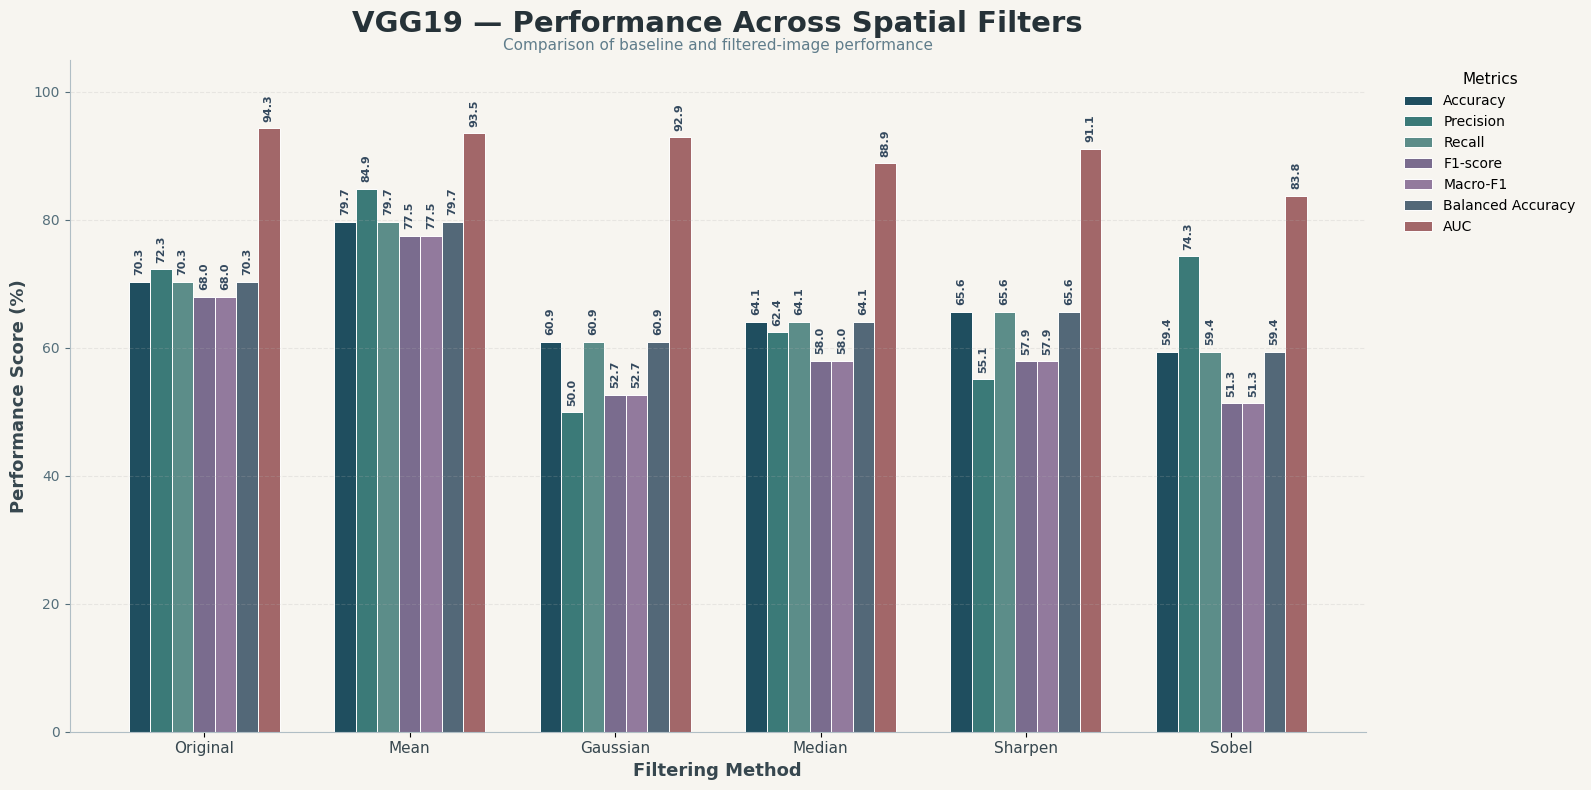

In [20]:
# ============================================================
# CELL — VGG19 OVERALL VISUALIZATION — NEW COLOR PALETTE
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# CREATE OVERALL VGG19 TABLE
# ============================================================

vgg19_table_data = []

for filter_name in FILTERS:

    key = f"VGG19_{filter_name}"
    result = experiment_results[key]

    vgg19_table_data.append({
        "Model": result["Model"],
        "Filter": result["Filter"],
        "Accuracy (%)": result["Accuracy"] * 100,
        "Precision (%)": result["Precision"] * 100,
        "Recall (%)": result["Recall"] * 100,
        "F1-score (%)": result["F1-score"] * 100,
        "Macro-F1 (%)": result["Macro-F1"] * 100,
        "Balanced Accuracy (%)": result["Balanced Accuracy"] * 100,
        "AUC (%)": result["AUC"] * 100
    })

vgg19_table = pd.DataFrame(vgg19_table_data)

metric_columns = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)",
    "Macro-F1 (%)",
    "Balanced Accuracy (%)",
    "AUC (%)"
]

vgg19_table[metric_columns] = vgg19_table[metric_columns].round(2)

print("\n" + "=" * 100)
print("VGG19 — OVERALL COMPARISON TABLE")
print("=" * 100)

display(vgg19_table)

# Save table
vgg19_table.to_csv(
    "VGG19_Overall_Results.csv",
    index=False
)

print("\nVGG19 experiments completed successfully.")
print("Results saved as: VGG19_Overall_Results.csv")


metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)",
    "Macro-F1 (%)",
    "Balanced Accuracy (%)",
    "AUC (%)"
]

filters = vgg19_table["Filter"].tolist()

x = np.arange(len(filters))
width = 0.105

# Elegant cohesive palette
colors = [
    "#1F4E5F",  # Deep teal
    "#3B7A78",  # Muted teal
    "#5C8D89",  # Sage teal
    "#7A6C8E",  # Muted purple
    "#927A9D",  # Soft mauve
    "#536878",  # Slate blue
    "#A26769"   # Dusty rose
]

fig, ax = plt.subplots(figsize=(16, 8))

# Background
fig.patch.set_facecolor("#F7F5F0")
ax.set_facecolor("#F7F5F0")

# Draw bars
for i, metric in enumerate(metrics):

    values = vgg19_table[metric].values

    bars = ax.bar(
        x + (i - 3) * width,
        values,
        width,
        label=metric.replace(" (%)", ""),
        color=colors[i],
        edgecolor="white",
        linewidth=0.7
    )

    # Value labels
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            color="#34495E",
            rotation=90
        )

# Title
ax.set_title(
    "VGG19 — Performance Across Spatial Filters",
    fontsize=21,
    fontweight="bold",
    color="#263238",
    pad=20
)

ax.text(
    0.5,
    1.015,
    "Comparison of baseline and filtered-image performance",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="#607D8B"
)

# Axis labels
ax.set_xlabel(
    "Filtering Method",
    fontsize=13,
    fontweight="bold",
    color="#37474F"
)

ax.set_ylabel(
    "Performance Score (%)",
    fontsize=13,
    fontweight="bold",
    color="#37474F"
)

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(
    filters,
    fontsize=11,
    color="#37474F"
)

# Y-axis
ax.set_ylim(0, 105)

ax.tick_params(
    axis="y",
    labelsize=10,
    colors="#546E7A"
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.22
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#B0BEC5")
ax.spines["bottom"].set_color("#B0BEC5")

# Legend
legend = ax.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()


# MODEL(2)-  EfficientNet-B0

In [21]:
# ============================================================
# CELL — EfficientNet-B0 — ALL 6 FILTERS
# ============================================================

print("=" * 70)
print("EFFICIENTNET-B0 — ALL 6 FILTER EXPERIMENTS")
print("=" * 70)

efficientnet_results = {}

for filter_name in FILTERS:

    print("\n" + "=" * 70)
    print(f"EfficientNet-B0 — {filter_name}")
    print("=" * 70)

    # Create a fresh model
    model = create_model("EfficientNet-B0")

    # Train
    history = train_model(
        model,
        train_loaders[filter_name],
        val_loaders[filter_name]
    )

    # Evaluate
    results = evaluate_model(
        model,
        test_loaders[filter_name]
    )

    # Save results
    key = f"EfficientNet-B0_{filter_name}"

    experiment_results[key] = {
        "Model": "EfficientNet-B0",
        "Filter": filter_name,
        "Accuracy": results["accuracy"],
        "Precision": results["precision"],
        "Recall": results["recall"],
        "F1-score": results["f1"],
        "Macro-F1": results["macro_f1"],
        "Balanced Accuracy": results["balanced_accuracy"],
        "AUC": results["auc"],
        "Confusion Matrix": results["confusion_matrix"],
        "Classification Report": results["classification_report"]
    }

    experiment_histories[key] = history

    efficientnet_results[key] = results

    print("\nRESULTS")
    print("-" * 50)
    print(f"Accuracy          : {results['accuracy']:.2%}")
    print(f"Precision         : {results['precision']:.2%}")
    print(f"Recall            : {results['recall']:.2%}")
    print(f"F1-score          : {results['f1']:.2%}")
    print(f"Macro-F1          : {results['macro_f1']:.2%}")
    print(f"Balanced Accuracy : {results['balanced_accuracy']:.2%}")
    print(f"AUC               : {results['auc']:.2%}")

    # Free GPU memory
    del model
    torch.cuda.empty_cache()


# ============================================================
# CREATE OVERALL EFFICIENTNET-B0 TABLE
# ============================================================

efficientnet_table_data = []

for filter_name in FILTERS:

    key = f"EfficientNet-B0_{filter_name}"
    result = experiment_results[key]

    efficientnet_table_data.append({
        "Model": result["Model"],
        "Filter": result["Filter"],
        "Accuracy (%)": result["Accuracy"] * 100,
        "Precision (%)": result["Precision"] * 100,
        "Recall (%)": result["Recall"] * 100,
        "F1-score (%)": result["F1-score"] * 100,
        "Macro-F1 (%)": result["Macro-F1"] * 100,
        "Balanced Accuracy (%)": result["Balanced Accuracy"] * 100,
        "AUC (%)": result["AUC"] * 100
    })

efficientnet_table = pd.DataFrame(efficientnet_table_data)

metric_columns = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)",
    "Macro-F1 (%)",
    "Balanced Accuracy (%)",
    "AUC (%)"
]

efficientnet_table[metric_columns] = efficientnet_table[metric_columns].round(2)

print("\n" + "=" * 100)
print("EFFICIENTNET-B0 — OVERALL COMPARISON TABLE")
print("=" * 100)

display(efficientnet_table)

# Save table
efficientnet_table.to_csv(
    "EfficientNet-B0_Overall_Results.csv",
    index=False
)

print("\nEfficientNet-B0 experiments completed successfully.")
print("Results saved as: EfficientNet-B0_Overall_Results.csv")

EFFICIENTNET-B0 — ALL 6 FILTER EXPERIMENTS

EfficientNet-B0 — Original
Epoch [01/10] | Train Loss: 1.2187 | Train Acc: 0.4985 | Val Loss: 1.0302 | Val Acc: 0.6208
Epoch [02/10] | Train Loss: 0.8165 | Train Acc: 0.7182 | Val Loss: 0.7398 | Val Acc: 0.7248
Epoch [03/10] | Train Loss: 0.5870 | Train Acc: 0.7879 | Val Loss: 0.6034 | Val Acc: 0.7798
Epoch [04/10] | Train Loss: 0.4577 | Train Acc: 0.8338 | Val Loss: 0.5312 | Val Acc: 0.8012
Epoch [05/10] | Train Loss: 0.3856 | Train Acc: 0.8645 | Val Loss: 0.5165 | Val Acc: 0.8165
Epoch [06/10] | Train Loss: 0.3345 | Train Acc: 0.8821 | Val Loss: 0.5020 | Val Acc: 0.8196
Epoch [07/10] | Train Loss: 0.2896 | Train Acc: 0.8951 | Val Loss: 0.4983 | Val Acc: 0.8135
Epoch [08/10] | Train Loss: 0.2609 | Train Acc: 0.9204 | Val Loss: 0.4965 | Val Acc: 0.8135
Epoch [09/10] | Train Loss: 0.1950 | Train Acc: 0.9410 | Val Loss: 0.4966 | Val Acc: 0.8165
Epoch [10/10] | Train Loss: 0.1850 | Train Acc: 0.9456 | Val Loss: 0.5338 | Val Acc: 0.8196

RESULTS


,Model,Filter,Accuracy (%),Precision (%),Recall (%),F1-score (%),Macro-F1 (%),Balanced Accuracy (%),AUC (%)
0,EfficientNet-B0,Original,68.75,78.74,68.75,63.70,63.70,68.75,94.14
1,EfficientNet-B0,Mean,71.88,80.14,71.88,67.54,67.54,71.88,96.42
2,EfficientNet-B0,Gaussian,76.56,83.16,76.56,74.12,74.12,76.56,96.39
3,EfficientNet-B0,Median,78.12,83.75,78.12,75.32,75.32,78.12,94.63
4,EfficientNet-B0,Sharpen,78.12,86.34,78.12,76.96,76.96,78.12,97.92
5,EfficientNet-B0,Sobel,51.56,54.70,51.56,48.12,48.12,51.56,79.26



EfficientNet-B0 experiments completed successfully.
Results saved as: EfficientNet-B0_Overall_Results.csv


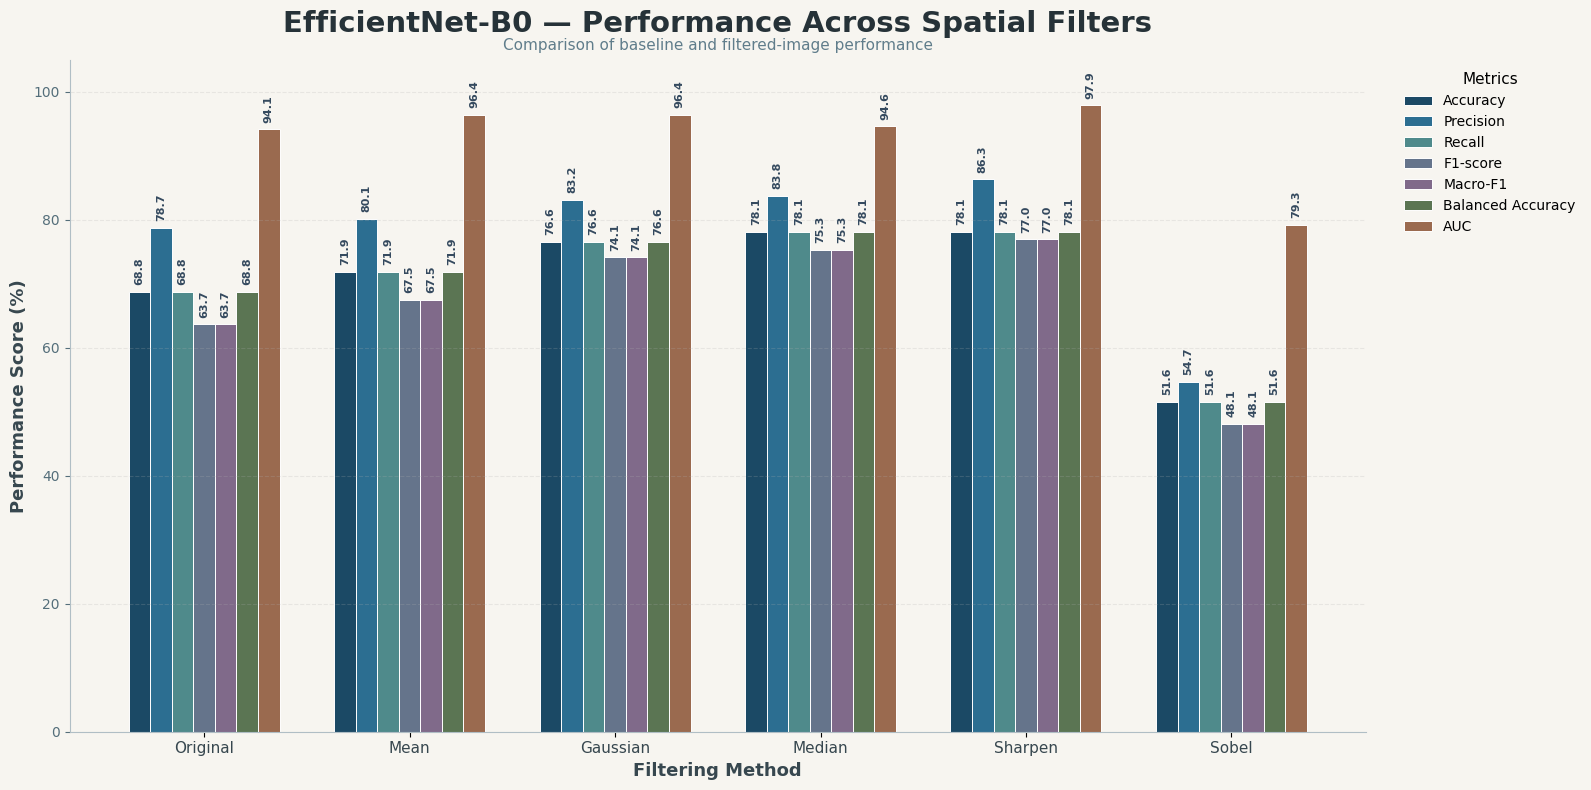

In [22]:
# ============================================================
# CELL — EFFICIENTNET-B0 OVERALL VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)",
    "Macro-F1 (%)",
    "Balanced Accuracy (%)",
    "AUC (%)"
]

filters = efficientnet_table["Filter"].tolist()

x = np.arange(len(filters))
width = 0.105

# Professional muted palette
colors = [
    "#1B4965",
    "#2C6E91",
    "#4F8A8B",
    "#65748B",
    "#806A8A",
    "#5B7553",
    "#9A6A4F"
]

fig, ax = plt.subplots(figsize=(16, 8))

fig.patch.set_facecolor("#F7F5F0")
ax.set_facecolor("#F7F5F0")

# Plot each metric
for i, metric in enumerate(metrics):

    values = efficientnet_table[metric].values

    bars = ax.bar(
        x + (i - 3) * width,
        values,
        width,
        label=metric.replace(" (%)", ""),
        color=colors[i],
        edgecolor="white",
        linewidth=0.7
    )

    # Values above bars
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            color="#34495E",
            rotation=90
        )

# Title
ax.set_title(
    "EfficientNet-B0 — Performance Across Spatial Filters",
    fontsize=21,
    fontweight="bold",
    color="#263238",
    pad=20
)

ax.text(
    0.5,
    1.015,
    "Comparison of baseline and filtered-image performance",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="#607D8B"
)

# Axis labels
ax.set_xlabel(
    "Filtering Method",
    fontsize=13,
    fontweight="bold",
    color="#37474F"
)

ax.set_ylabel(
    "Performance Score (%)",
    fontsize=13,
    fontweight="bold",
    color="#37474F"
)

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(
    filters,
    fontsize=11,
    color="#37474F"
)

# Y-axis
ax.set_ylim(0, 105)

ax.tick_params(
    axis="y",
    labelsize=10,
    colors="#546E7A"
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.22
)

# Remove unnecessary borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#B0BEC5")
ax.spines["bottom"].set_color("#B0BEC5")

# Legend
ax.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()

# MODEL(3)-AlexNet

In [23]:
# ============================================================
# CELL — ALEXNET — ALL 6 FILTERS
# ============================================================

print("=" * 70)
print("ALEXNET — ALL 6 FILTER EXPERIMENTS")
print("=" * 70)

alexnet_results = {}

for filter_name in FILTERS:

    print("\n" + "=" * 70)
    print(f"AlexNet — {filter_name}")
    print("=" * 70)

    # Fresh AlexNet model
    model = create_model("AlexNet")

    # Train for 10 epochs
    history = train_model(
        model,
        train_loaders[filter_name],
        val_loaders[filter_name]
    )

    print("\nTraining completed.")

    # Evaluate
    results = evaluate_model(
        model,
        test_loaders[filter_name]
    )

    # Save experiment
    key = f"AlexNet_{filter_name}"

    experiment_results[key] = {
        "Model": "AlexNet",
        "Filter": filter_name,
        "Accuracy": results["accuracy"],
        "Precision": results["precision"],
        "Recall": results["recall"],
        "F1-score": results["f1"],
        "Macro-F1": results["macro_f1"],
        "Balanced Accuracy": results["balanced_accuracy"],
        "AUC": results["auc"],
        "Confusion Matrix": results["confusion_matrix"],
        "Classification Report": results["classification_report"]
    }

    experiment_histories[key] = history
    alexnet_results[key] = results

    # Print results
    print("\nRESULTS")
    print("-" * 50)
    print(f"Accuracy          : {results['accuracy']:.2%}")
    print(f"Precision         : {results['precision']:.2%}")
    print(f"Recall            : {results['recall']:.2%}")
    print(f"F1-score          : {results['f1']:.2%}")
    print(f"Macro-F1          : {results['macro_f1']:.2%}")
    print(f"Balanced Accuracy : {results['balanced_accuracy']:.2%}")
    print(f"AUC               : {results['auc']:.2%}")

    # Clear GPU memory
    del model
    torch.cuda.empty_cache()


# ============================================================
# CREATE ALEXNET OVERALL TABLE
# ============================================================

alexnet_table_data = []

for filter_name in FILTERS:

    key = f"AlexNet_{filter_name}"
    result = experiment_results[key]

    alexnet_table_data.append({
        "Model": result["Model"],
        "Filter": result["Filter"],
        "Accuracy (%)": result["Accuracy"] * 100,
        "Precision (%)": result["Precision"] * 100,
        "Recall (%)": result["Recall"] * 100,
        "F1-score (%)": result["F1-score"] * 100,
        "Macro-F1 (%)": result["Macro-F1"] * 100,
        "Balanced Accuracy (%)": result["Balanced Accuracy"] * 100,
        "AUC (%)": result["AUC"] * 100
    })

alexnet_table = pd.DataFrame(alexnet_table_data)

metric_columns = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)",
    "Macro-F1 (%)",
    "Balanced Accuracy (%)",
    "AUC (%)"
]

alexnet_table[metric_columns] = alexnet_table[metric_columns].round(2)

print("\n" + "=" * 100)
print("ALEXNET — OVERALL COMPARISON TABLE")
print("=" * 100)

display(alexnet_table)

# Save results
alexnet_table.to_csv(
    "AlexNet_Overall_Results.csv",
    index=False
)

print("\nAlexNet experiments completed successfully.")
print("Results saved as: AlexNet_Overall_Results.csv")

ALEXNET — ALL 6 FILTER EXPERIMENTS

AlexNet — Original
Epoch [01/10] | Train Loss: 0.9805 | Train Acc: 0.5804 | Val Loss: 0.7937 | Val Acc: 0.6850
Epoch [02/10] | Train Loss: 0.6503 | Train Acc: 0.7619 | Val Loss: 0.7053 | Val Acc: 0.7217
Epoch [03/10] | Train Loss: 0.5814 | Train Acc: 0.7894 | Val Loss: 0.7041 | Val Acc: 0.7187
Epoch [04/10] | Train Loss: 0.5091 | Train Acc: 0.8109 | Val Loss: 0.5703 | Val Acc: 0.7706
Epoch [05/10] | Train Loss: 0.4685 | Train Acc: 0.8254 | Val Loss: 0.7048 | Val Acc: 0.7278
Epoch [06/10] | Train Loss: 0.3917 | Train Acc: 0.8606 | Val Loss: 0.5791 | Val Acc: 0.7890
Epoch [07/10] | Train Loss: 0.3372 | Train Acc: 0.8813 | Val Loss: 0.6021 | Val Acc: 0.7951
Epoch [08/10] | Train Loss: 0.3327 | Train Acc: 0.8798 | Val Loss: 0.6543 | Val Acc: 0.7584
Epoch [09/10] | Train Loss: 0.3054 | Train Acc: 0.8813 | Val Loss: 0.7228 | Val Acc: 0.7523
Epoch [10/10] | Train Loss: 0.3017 | Train Acc: 0.8951 | Val Loss: 0.6445 | Val Acc: 0.7951

Training completed.

RES

,Model,Filter,Accuracy (%),Precision (%),Recall (%),F1-score (%),Macro-F1 (%),Balanced Accuracy (%),AUC (%)
0,AlexNet,Original,67.19,66.67,67.19,66.81,66.81,67.19,90.04
1,AlexNet,Mean,70.31,78.32,70.31,67.45,67.45,70.31,89.26
2,AlexNet,Gaussian,62.50,49.13,62.50,54.08,54.08,62.50,90.23
3,AlexNet,Median,65.62,62.40,65.62,60.69,60.69,65.62,87.60
4,AlexNet,Sharpen,71.88,77.08,71.88,68.44,68.44,71.88,87.21
5,AlexNet,Sobel,53.12,43.13,53.12,45.74,45.74,53.12,73.73



AlexNet experiments completed successfully.
Results saved as: AlexNet_Overall_Results.csv


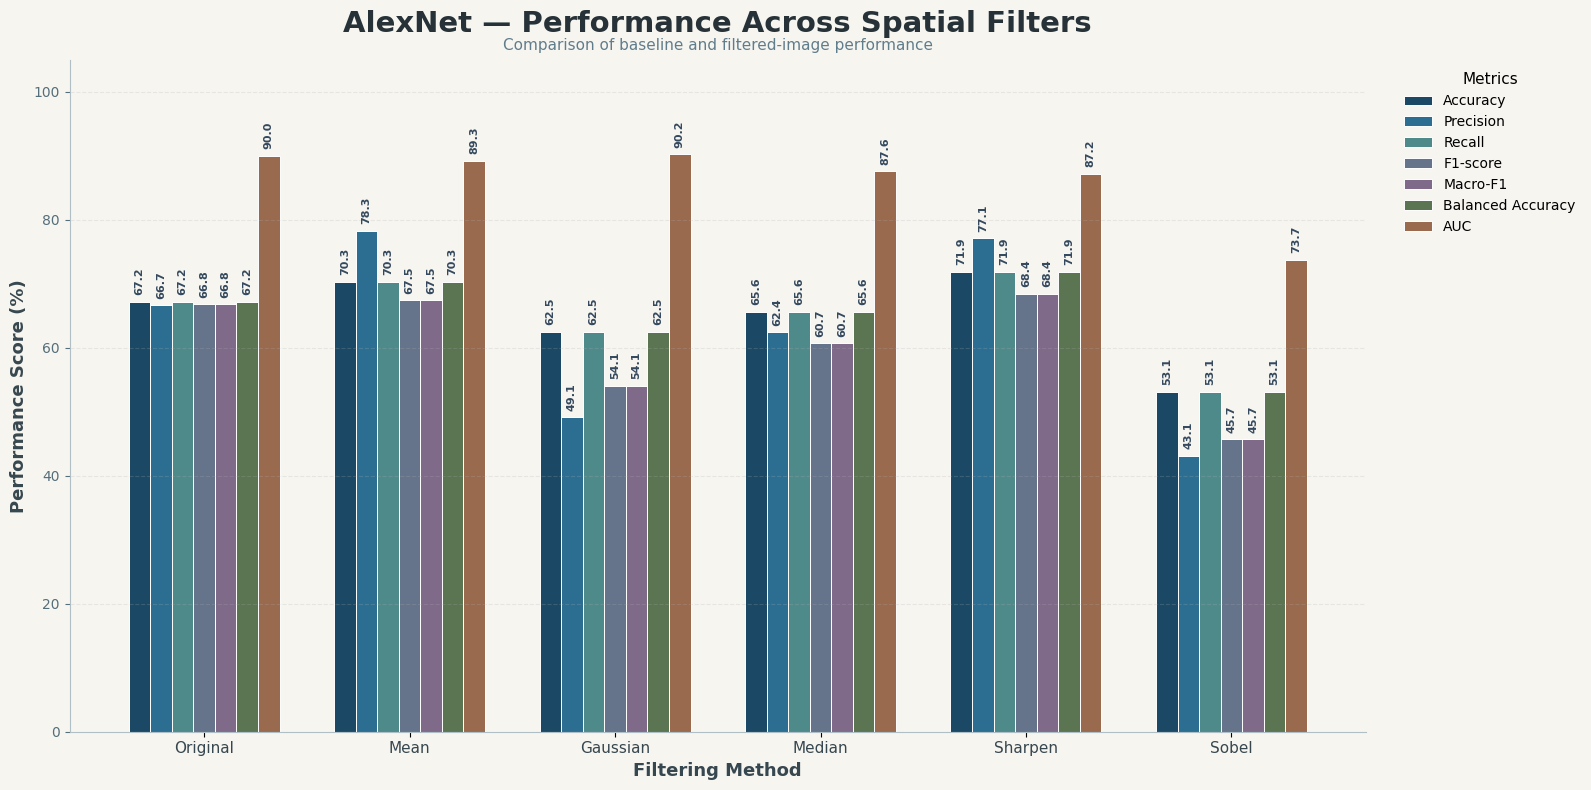

In [24]:
# ============================================================
# CELL — ALEXNET OVERALL VISUALIZATION
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

metrics = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)",
    "Macro-F1 (%)",
    "Balanced Accuracy (%)",
    "AUC (%)"
]

filters = alexnet_table["Filter"].tolist()

x = np.arange(len(filters))
width = 0.105

# Professional muted palette
colors = [
    "#1B4965",
    "#2C6E91",
    "#4F8A8B",
    "#65748B",
    "#806A8A",
    "#5B7553",
    "#9A6A4F"
]

fig, ax = plt.subplots(figsize=(16, 8))

fig.patch.set_facecolor("#F7F5F0")
ax.set_facecolor("#F7F5F0")

# Plot all metrics
for i, metric in enumerate(metrics):

    values = alexnet_table[metric].values

    bars = ax.bar(
        x + (i - 3) * width,
        values,
        width,
        label=metric.replace(" (%)", ""),
        color=colors[i],
        edgecolor="white",
        linewidth=0.7
    )

    # Add values above bars
    for bar, value in zip(bars, values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.1f}",
            ha="center",
            va="bottom",
            fontsize=8,
            fontweight="bold",
            color="#34495E",
            rotation=90
        )

# Title
ax.set_title(
    "AlexNet — Performance Across Spatial Filters",
    fontsize=21,
    fontweight="bold",
    color="#263238",
    pad=20
)

ax.text(
    0.5,
    1.015,
    "Comparison of baseline and filtered-image performance",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="#607D8B"
)

# Axis labels
ax.set_xlabel(
    "Filtering Method",
    fontsize=13,
    fontweight="bold",
    color="#37474F"
)

ax.set_ylabel(
    "Performance Score (%)",
    fontsize=13,
    fontweight="bold",
    color="#37474F"
)

# X-axis
ax.set_xticks(x)
ax.set_xticklabels(
    filters,
    fontsize=11,
    color="#37474F"
)

# Y-axis
ax.set_ylim(0, 105)

ax.tick_params(
    axis="y",
    labelsize=10,
    colors="#546E7A"
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.22
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#B0BEC5")
ax.spines["bottom"].set_color("#B0BEC5")

# Legend
ax.legend(
    title="Metrics",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=10,
    title_fontsize=11
)

plt.tight_layout()
plt.show()

In [25]:
# ============================================================
# CELL — FINAL COMPARISON TABLE
# VGG19 + EfficientNet-B0 + AlexNet
# ============================================================

all_results = []

MODEL_ORDER = [
    "VGG19",
    "EfficientNet-B0",
    "AlexNet"
]

for model_name in MODEL_ORDER:

    for filter_name in FILTERS:

        key = f"{model_name}_{filter_name}"

        if key in experiment_results:

            result = experiment_results[key]

            all_results.append({
                "Model": result["Model"],
                "Filter": result["Filter"],
                "Accuracy (%)": result["Accuracy"] * 100,
                "Precision (%)": result["Precision"] * 100,
                "Recall (%)": result["Recall"] * 100,
                "F1-score (%)": result["F1-score"] * 100,
                "Macro-F1 (%)": result["Macro-F1"] * 100,
                "Balanced Accuracy (%)": result["Balanced Accuracy"] * 100,
                "AUC (%)": result["AUC"] * 100
            })

# Create final DataFrame
final_results_table = pd.DataFrame(all_results)

# Round metrics
metric_columns = [
    "Accuracy (%)",
    "Precision (%)",
    "Recall (%)",
    "F1-score (%)",
    "Macro-F1 (%)",
    "Balanced Accuracy (%)",
    "AUC (%)"
]

final_results_table[metric_columns] = (
    final_results_table[metric_columns].round(2)
)

# Display
print("=" * 120)
print("TASK 02 — FINAL MODEL AND FILTER COMPARISON")
print("=" * 120)

display(final_results_table)

# Save CSV
final_results_table.to_csv(
    "Task02_Final_Comparison.csv",
    index=False
)

print("\nFinal comparison table saved as:")
print("Task02_Final_Comparison.csv")

print("\nTotal experiments:", len(final_results_table))
print("Expected experiments:", len(MODEL_ORDER) * len(FILTERS))

TASK 02 — FINAL MODEL AND FILTER COMPARISON


,Model,Filter,Accuracy (%),Precision (%),Recall (%),F1-score (%),Macro-F1 (%),Balanced Accuracy (%),AUC (%)
0,VGG19,Original,70.31,72.26,70.31,67.99,67.99,70.31,94.30
1,VGG19,Mean,79.69,84.88,79.69,77.53,77.53,79.69,93.55
2,VGG19,Gaussian,60.94,49.96,60.94,52.66,52.66,60.94,92.87
3,VGG19,Median,64.06,62.39,64.06,57.97,57.97,64.06,88.87
4,VGG19,Sharpen,65.62,55.07,65.62,57.88,57.88,65.62,91.08
5,VGG19,Sobel,59.38,74.33,59.38,51.30,51.30,59.38,83.79
6,EfficientNet-B0,Original,68.75,78.74,68.75,63.70,63.70,68.75,94.14
7,EfficientNet-B0,Mean,71.88,80.14,71.88,67.54,67.54,71.88,96.42
8,EfficientNet-B0,Gaussian,76.56,83.16,76.56,74.12,74.12,76.56,96.39
9,EfficientNet-B0,Median,78.12,83.75,78.12,75.32,75.32,78.12,94.63



Final comparison table saved as:
Task02_Final_Comparison.csv

Total experiments: 18
Expected experiments: 18


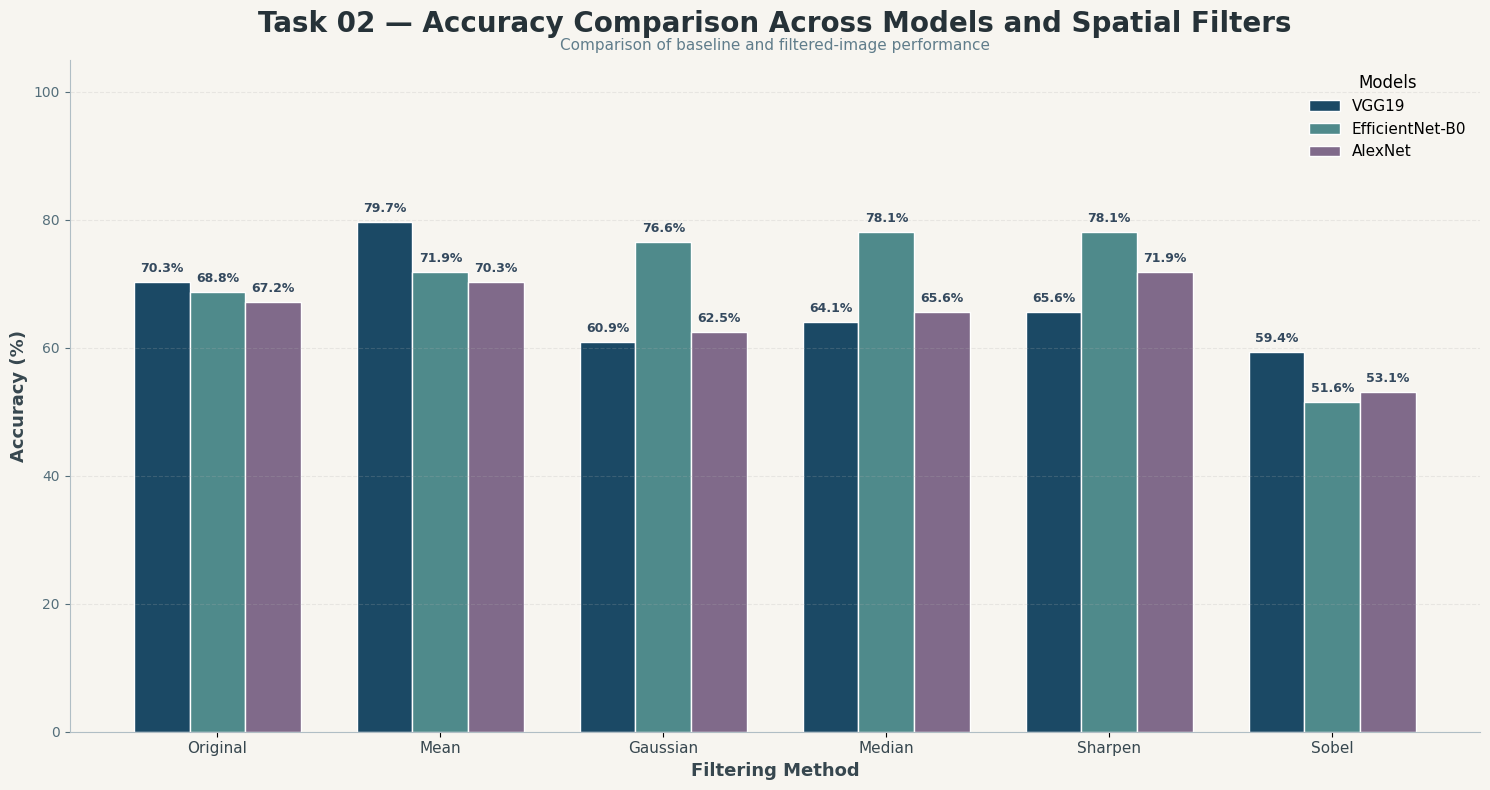

In [26]:
# ============================================================
# CELL — FINAL ACCURACY COMPARISON
# VGG19 + EfficientNet-B0 + AlexNet
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# ------------------------------------------------------------
# Prepare data
# ------------------------------------------------------------

models_list = [
    "VGG19",
    "EfficientNet-B0",
    "AlexNet"
]

filters = [
    "Original",
    "Mean",
    "Gaussian",
    "Median",
    "Sharpen",
    "Sobel"
]

x = np.arange(len(filters))
width = 0.25

# Get accuracy values
vgg19_accuracy = [
    final_results_table[
        (final_results_table["Model"] == "VGG19") &
        (final_results_table["Filter"] == filter_name)
    ]["Accuracy (%)"].iloc[0]
    for filter_name in filters
]

efficientnet_accuracy = [
    final_results_table[
        (final_results_table["Model"] == "EfficientNet-B0") &
        (final_results_table["Filter"] == filter_name)
    ]["Accuracy (%)"].iloc[0]
    for filter_name in filters
]

alexnet_accuracy = [
    final_results_table[
        (final_results_table["Model"] == "AlexNet") &
        (final_results_table["Filter"] == filter_name)
    ]["Accuracy (%)"].iloc[0]
    for filter_name in filters
]

# ------------------------------------------------------------
# Create graph
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 8))

fig.patch.set_facecolor("#F7F5F0")
ax.set_facecolor("#F7F5F0")

# Model colors
vgg_color = "#1B4965"
efficient_color = "#4F8A8B"
alex_color = "#806A8A"

bars1 = ax.bar(
    x - width,
    vgg19_accuracy,
    width,
    label="VGG19",
    color=vgg_color,
    edgecolor="white"
)

bars2 = ax.bar(
    x,
    efficientnet_accuracy,
    width,
    label="EfficientNet-B0",
    color=efficient_color,
    edgecolor="white"
)

bars3 = ax.bar(
    x + width,
    alexnet_accuracy,
    width,
    label="AlexNet",
    color=alex_color,
    edgecolor="white"
)

# ------------------------------------------------------------
# Add values
# ------------------------------------------------------------

for bars in [bars1, bars2, bars3]:

    for bar in bars:

        value = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
            color="#34495E"
        )

# ------------------------------------------------------------
# Titles
# ------------------------------------------------------------

ax.set_title(
    "Task 02 — Accuracy Comparison Across Models and Spatial Filters",
    fontsize=20,
    fontweight="bold",
    color="#263238",
    pad=20
)

ax.text(
    0.5,
    1.015,
    "Comparison of baseline and filtered-image performance",
    transform=ax.transAxes,
    ha="center",
    fontsize=11,
    color="#607D8B"
)

# ------------------------------------------------------------
# Labels
# ------------------------------------------------------------

ax.set_xlabel(
    "Filtering Method",
    fontsize=13,
    fontweight="bold",
    color="#37474F"
)

ax.set_ylabel(
    "Accuracy (%)",
    fontsize=13,
    fontweight="bold",
    color="#37474F"
)

ax.set_xticks(x)
ax.set_xticklabels(
    filters,
    fontsize=11,
    color="#37474F"
)

# ------------------------------------------------------------
# Y-axis
# ------------------------------------------------------------

ax.set_ylim(0, 105)

ax.tick_params(
    axis="y",
    labelsize=10,
    colors="#546E7A"
)

# Grid
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.8,
    alpha=0.22
)

# Clean borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#B0BEC5")
ax.spines["bottom"].set_color("#B0BEC5")

# Legend
ax.legend(
    title="Models",
    loc="upper right",
    frameon=False,
    fontsize=11,
    title_fontsize=12
)

plt.tight_layout()
plt.show()